## 社群媒體分析期末報告 - PTT八卦版台積公司相關討論文字分析
### 第十六組
### 組員：M144020002 吳俊廷、B124020008 李怡君
### 動機與分析目的：
台積電不僅是台灣資本市場最具代表性的權值股，也是全球半導體供應鏈與 AI 產業敘事中的核心企業，其股價表現、法說資訊、國際政治經濟事件與產業新聞，往往會迅速反映在投資社群的討論熱度與情緒變化上。PTT股票板作為台灣散戶投資者高度活躍的公開討論場域，累積了大量即時、口語且具有互動性的市場觀察，因此適合作為社群媒體分析的研究文本。

本研究以「台積電」相關討論為主軸，透過文字探勘與社群網路分析方法，觀察投資人如何描述台積電與整體市場，並進一步回答三個問題：第一，台積電相關文章與推文互動在時間上如何變化；第二，討論中反覆出現的關鍵詞、主題與情緒傾向為何；第三，PTT 使用者之間是否形成具影響力的互動節點與討論網絡。藉由結合詞頻、TF-IDF、情緒字典、主題模型、分類模型與網路中心性指標，本報告希望從「文本內容」與「社群互動」兩個面向，描繪台積電議題在散戶投資社群中的討論樣貌。

### 資料集描述：
- 資料來源：PTT Stock 板
- 搜尋關鍵字：台積電、美積電、2330、TSMC
- 排除關鍵字：詐騙、飆股、加LINE、抽獎、加我、追蹤、飆漲、側翼、網軍、帶風向、老師、關注、保證、領取
- 搜尋日期：2025/06/01 至 2026/06/01
- 實際資料期間：2025/06/01 01:18:14 至 2026/05/30 02:37:59
- 資料規模：共 2,279 篇文章、316,501 則推文，涵蓋 724 位發文者
- 主要欄位：文章標題、文章時間、發文者、文章內容、推文狀態、推文者、推文內容與推文時間

### 資料分析大綱：
1. 資料讀取與基本檢查：確認文章數、欄位型態、日期範圍、重複資料與看板分布。
2. 推文解析與互動指標：將推、噓、箭頭解析為結構化資料，建立文章層級的互動量、推噓比與淨推文數。
3. 時間趨勢分析：觀察每日文章量、推文量與情緒互動變化，辨識討論熱度集中的時間點。
4. 文字前處理與斷詞：清理 PTT 常見雜訊、停用詞與標點符號，建立可供後續分析使用的詞彙資料。
5. 詞頻、文字雲與 TF-IDF：比較高頻詞與具區辨力的關鍵詞，掌握台積電討論中的核心語彙。
6. LIWC 與財經詞典情緒分析：以正負向詞彙衡量文章情緒，分析市場討論中的樂觀與悲觀訊號。
7. N-gram、詞彙相關與共現網路：從 bigram、trigram、詞彙相關與關鍵詞共現關係，探索討論語境中的詞彙結構。
8. 文章相似度與 LDA 主題模型：辨識文章之間的內容相近性，並歸納台積電相關討論的主要主題。
9. 高互動文章分類模型：建立文章特徵與互動表現之間的關聯，分析哪些文字或情緒特徵可能帶來較高討論度。
10. 社群網路分析：以推文者與發文者建立互動網路，計算 PageRank、Eigenvector、HITS、Betweenness 等中心性指標，找出具影響力的使用者與網路結構特徵。

## 1. 初始設定與資料路徑

In [1]:
# 匯入基礎資料處理、繪圖、文字處理與模型套件。
from pathlib import Path
from collections import Counter, defaultdict
import ast
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 嘗試設定中文字型；不同作業系統字型名稱不同，若找不到只會影響圖上的中文字顯示。
plt.rcParams['font.sans-serif'] = [
    'Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'Noto Sans CJK TC',
    'Arial Unicode MS', 'SimHei', 'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False

# 建立穩健的路徑搜尋函式，避免因 Jupyter 啟動位置不同而讀不到檔案。
CWD = Path.cwd()
DATA_CANDIDATES = [
    CWD / 'TSMCdata.csv',
    CWD / 'SMA_FinalProject' / 'TSMCdata.csv',
    CWD.parent / 'SMA_FinalProject' / 'TSMCdata.csv',
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('找不到 TSMCdata.csv，請確認 notebook 位於專案資料夾內。')

# 找出專案根目錄與輸出資料夾。
PROJECT_ROOT = DATA_PATH.parent.parent if DATA_PATH.parent.name == 'SMA_FinalProject' else CWD
FINAL_DIR = DATA_PATH.parent
OUTPUT_DIR = FINAL_DIR / 'output'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
for d in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DICT_DIR_CANDIDATES = [
    PROJECT_ROOT / 'SMA_FinalProject' / 'dict',
    #/Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/dict
]
DICT_DIR = next((p for p in DICT_DIR_CANDIDATES if p.exists()), None)
print(f'資料路徑：{DATA_PATH}')
print(f'字典路徑：{DICT_DIR}')
print(f'輸出資料夾：{OUTPUT_DIR}')

資料路徑：/Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/TSMCdata.csv
字典路徑：/Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/dict
輸出資料夾：/Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/output


## 2. 讀取資料與基本檢查

In [2]:
# 讀取原始資料，並先保留一份 raw_df 。
# artDate 與 insertedDate 轉成 datetime，後續才能做時間序列分析。
raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()

df['artDate'] = pd.to_datetime(df['artDate'], errors='coerce')
df['insertedDate'] = pd.to_datetime(df['insertedDate'], errors='coerce')
df['artContent'] = df['artContent'].fillna('').astype(str)
df['artTitle'] = df['artTitle'].fillna('').astype(str)
df['artPoster'] = df['artPoster'].fillna('unknown').astype(str)
df['artCatagory'] = df['artCatagory'].fillna('unknown').astype(str)
df['artComment'] = df['artComment'].fillna('[]').astype(str)

# 建立文章日期欄位，便於依日、週、月彙總。
df['date'] = df['artDate'].dt.date
df['week'] = df['artDate'].dt.to_period('W').astype(str)
df['month'] = df['artDate'].dt.to_period('M').astype(str)

# 輸出資料規模、欄位、日期範圍與缺值概況。
print('資料筆數與欄位數：', df.shape)
print('日期範圍：', df['artDate'].min(), '到', df['artDate'].max())
display(df.head(3))
display(pd.DataFrame({
    '欄位': df.columns,
    '缺值數': df.isna().sum().values,
    '資料型態': df.dtypes.astype(str).values,
}))

資料筆數與欄位數： (2279, 14)
日期範圍： 2025-06-01 01:18:14 到 2026-05-30 02:37:59


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource,date,week,month
0,1,https://www.ptt.cc/bbs/Stock/M.1748711896.A.57...,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,haha98,Stock,原文標題：\n美股35年來最強5月表現 後續看川普與就業\n\n原文連結：\nhttps:/...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""bob120400"", ...",114.136.228.129,2025-06-01 01:32:06,ptt,2025-06-01,2025-05-26/2025-06-01,2025-06
1,2,https://www.ptt.cc/bbs/Stock/M.1748732942.A.E6...,[新聞]「大而美法案」可對外資課稅施俊吉：美關稅戰升級資本戰,2025-06-01 07:08:59,kof70380,Stock,原文標題：\n\n「大而美法案」可對外資課稅 施俊吉：美關稅戰升級資本戰\n\n原文連結：\...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""dosiris"", ""c...",114.39.208.161,2025-06-02 01:29:20,ptt,2025-06-01,2025-05-26/2025-06-01,2025-06
2,3,https://www.ptt.cc/bbs/Stock/M.1748769187.A.55...,[新聞]美國將中國部分產品的301關稅豁免延長至8,2025-06-01 17:13:04,SakuraHana,Stock,原文標題：美國將中國部分產品的301關稅豁免延長至8月底\n\n原文連結：\nhttps:/...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""godman362"", ...",36.228.148.118,2025-06-02 01:29:20,ptt,2025-06-01,2025-05-26/2025-06-01,2025-06


,欄位,缺值數,資料型態
0,system_id,0,int64
1,artUrl,0,str
2,artTitle,0,str
3,artDate,0,datetime64[us]
4,artPoster,0,str
5,artCatagory,0,str
6,artContent,0,str
7,artComment,0,str
8,e_ip,53,str
9,insertedDate,0,datetime64[us]


In [3]:
# 檢查重複文章、看板分布、發文者分布，這是 PTT 資料分析前的基本品質檢查。
summary = {
    '文章數': len(df),
    '不重複 URL 數': df['artUrl'].nunique(dropna=True),
    '重複 URL 筆數': int(len(df) - df['artUrl'].nunique(dropna=True)),
    '發文者數': df['artPoster'].nunique(dropna=True),
    '看板數': df['artCatagory'].nunique(dropna=True),
}
display(pd.Series(summary, name='基本摘要').to_frame())

display(df['artCatagory'].value_counts().rename_axis('看板').reset_index(name='文章數'))
display(df['artPoster'].value_counts().head(15).rename_axis('發文者').reset_index(name='文章數'))

,基本摘要
文章數,2279
不重複 URL 數,2279
重複 URL 筆數,0
發文者數,724
看板數,1


,看板,文章數
0,Stock,2279


,發文者,文章數
0,steward135,145
1,steveisaman,104
2,paidzou,102
3,laptic,92
4,saber50116,68
5,humbler,57
6,a926918tim,52
7,anti87,40
8,keel90135,29
9,q1a1,22


## 3. 解析推文

In [4]:
# artComment 欄位是字串化的推文 JSON 清單；這裡將它解析成 comment_df。
# 每一列 comment_df 代表一則推文，保留文章 id、標題、日期、推噓狀態、推文者與推文內容。
def parse_comment_list(value):
    if pd.isna(value) or str(value).strip() == '':
        return []
    try:
        parsed = json.loads(value)
    except Exception:
        try:
            parsed = ast.literal_eval(value)
        except Exception:
            return []
    return parsed if isinstance(parsed, list) else []

comment_rows = []
for _, row in df.iterrows():
    comments = parse_comment_list(row['artComment'])
    for idx, c in enumerate(comments):
        if not isinstance(c, dict):
            continue
        comment_rows.append({
            'system_id': row['system_id'],
            'artTitle': row['artTitle'],
            'artDate': row['artDate'],
            'date': row['date'],
            'comment_index': idx,
            'cmtStatus': str(c.get('cmtStatus', '')).strip(),
            'cmtPoster': str(c.get('cmtPoster', '')).strip(),
            'cmtContent': str(c.get('cmtContent', '')).strip(),
            'cmtDate': pd.to_datetime(c.get('cmtDate', pd.NaT), errors='coerce'),
        })

comment_df = pd.DataFrame(comment_rows)
print('推文總數：', len(comment_df))
display(comment_df.head())

推文總數： 316501


,system_id,artTitle,artDate,date,comment_index,cmtStatus,cmtPoster,cmtContent,cmtDate
0,1,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,2025-06-01,0,→,bob120400,:美元可以漲回去了嗎...,2025-06-01 01:22:00
1,1,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,2025-06-01,1,→,Jimny5566,:蛤？這是反彈上漲不是上升上漲耶，不是叫台灣鯛他,2025-06-01 01:24:00
2,1,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,2025-06-01,2,→,Jimny5566,:就是鯛魚，他是吳郭魚不是鯛魚。,2025-06-01 01:24:00
3,1,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,2025-06-01,3,→,Lenney33,:TACO看小丑沒有啦,2025-06-01 01:29:00
4,1,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,2025-06-01,4,噓,XDDDpupu5566,:四月先砸爛再來說最強五月,2025-06-01 01:32:00


In [5]:
# 將推、噓、箭頭統計回文章層級，形成後續互動分析與分類模型會用到的特徵。
if len(comment_df) > 0:
    status_pivot = pd.crosstab(comment_df['system_id'], comment_df['cmtStatus'])
else:
    status_pivot = pd.DataFrame()

for col in ['推', '噓', '→']:
    if col not in status_pivot.columns:
        status_pivot[col] = 0

status_pivot = status_pivot.rename(columns={'推': 'push_count', '噓': 'boo_count', '→': 'neutral_count'})
status_pivot['comment_count'] = status_pivot[['push_count', 'boo_count', 'neutral_count']].sum(axis=1)
status_pivot['push_ratio'] = status_pivot['push_count'] / status_pivot['comment_count'].replace(0, np.nan)
status_pivot['boo_ratio'] = status_pivot['boo_count'] / status_pivot['comment_count'].replace(0, np.nan)
status_pivot['net_push'] = status_pivot['push_count'] - status_pivot['boo_count']

# 合併回 df，沒有推文的文章補 0。
df = df.merge(status_pivot.reset_index(), on='system_id', how='left')
for col in ['push_count', 'boo_count', 'neutral_count', 'comment_count', 'net_push']:
    df[col] = df[col].fillna(0).astype(int)
for col in ['push_ratio', 'boo_ratio']:
    df[col] = df[col].fillna(0)

# 顯示互動指標摘要，方便了解資料的長尾程度。
display(df[['comment_count', 'push_count', 'boo_count', 'neutral_count', 'push_ratio', 'boo_ratio', 'net_push']].describe())
display(df.sort_values('comment_count', ascending=False)[['artDate', 'artTitle', 'artPoster', 'comment_count', 'push_count', 'boo_count', 'neutral_count', 'artUrl']].head(10))

,comment_count,push_count,boo_count,neutral_count,push_ratio,boo_ratio,net_push
count,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000
mean,138.877139,72.363756,12.257130,54.256253,0.528298,0.091085,60.106626
std,261.554831,143.930321,22.959304,103.675835,0.183134,0.105122,126.799256
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-138.000000
25%,28.000000,13.000000,1.000000,9.000000,0.415172,0.027027,9.000000
50%,59.000000,30.000000,4.000000,22.000000,0.533333,0.062295,24.000000
75%,122.000000,64.000000,11.000000,47.000000,0.649254,0.113301,52.000000
max,1428.000000,900.000000,260.000000,709.000000,1.000000,1.000000,789.000000


,artDate,artTitle,artPoster,comment_count,push_count,boo_count,neutral_count,artUrl
1832,2025-12-22 08:30:00,[閒聊]2025/12/22盤中閒聊,laptic,1428,900,111,417,https://www.ptt.cc/bbs/Stock/M.1766363402.A.D4...
291,2025-07-17 14:00:00,[閒聊]2025/07/17盤後閒聊,laptic,1425,771,104,550,https://www.ptt.cc/bbs/Stock/M.1752732002.A.53...
470,2025-07-31 14:00:00,[閒聊]2025/07/31盤後閒聊,laptic,1424,790,91,543,https://www.ptt.cc/bbs/Stock/M.1753941602.A.FC...
277,2025-07-16 14:00:00,[閒聊]2025/07/16盤後閒聊,laptic,1418,695,89,634,https://www.ptt.cc/bbs/Stock/M.1752645603.A.AE...
1972,2026-02-24 14:00:00,[閒聊]2026/02/24盤後閒聊,laptic,1417,679,69,669,https://www.ptt.cc/bbs/Stock/M.1771912808.A.30...
2001,2026-02-25 14:00:25,[閒聊]2026/02/25盤後閒聊,laptic,1410,746,104,560,https://www.ptt.cc/bbs/Stock/M.1771999233.A.37...
1467,2025-10-20 14:00:02,[閒聊]2025/10/20盤後閒聊,laptic,1410,726,92,592,https://www.ptt.cc/bbs/Stock/M.1760940005.A.8D...
371,2025-07-23 14:00:00,[閒聊]2025/07/23盤後閒聊,laptic,1408,802,102,504,https://www.ptt.cc/bbs/Stock/M.1753250402.A.5F...
2067,2026-03-05 14:00:00,[閒聊]2026/03/05盤後閒聊,laptic,1408,752,115,541,https://www.ptt.cc/bbs/Stock/M.1772690403.A.8A...
213,2025-07-02 14:00:00,[閒聊]2025/07/02盤後閒聊,laptic,1408,781,123,504,https://www.ptt.cc/bbs/Stock/M.1751436002.A.D5...


## 4. 時間趨勢與互動趨勢

In [6]:
# 依日期彙總文章數與推文互動，觀察台積電相關討論的時間趨勢。
daily = df.groupby('date', as_index=False).agg(
    article_count=('system_id', 'count'),
    comment_count=('comment_count', 'sum'),
    push_count=('push_count', 'sum'),
    boo_count=('boo_count', 'sum'),
    neutral_count=('neutral_count', 'sum'),
    avg_push_ratio=('push_ratio', 'mean'),
    avg_boo_ratio=('boo_ratio', 'mean'),
)
daily['date'] = pd.to_datetime(daily['date'])
daily['net_push'] = daily['push_count'] - daily['boo_count']

display(daily.head())
daily.to_csv(TABLE_DIR / 'daily_interaction_summary.csv', index=False, encoding='utf-8-sig')

,date,article_count,comment_count,push_count,boo_count,neutral_count,avg_push_ratio,avg_boo_ratio,net_push
0,2025-06-01,3,264,157,17,90,0.512068,0.098386,140
1,2025-06-02,4,122,58,24,40,0.402525,0.109436,34
2,2025-06-03,15,3183,1707,302,1174,0.597944,0.094965,1405
3,2025-06-04,7,1663,979,155,529,0.670909,0.063467,824
4,2025-06-05,11,1817,966,213,638,0.472438,0.119423,753


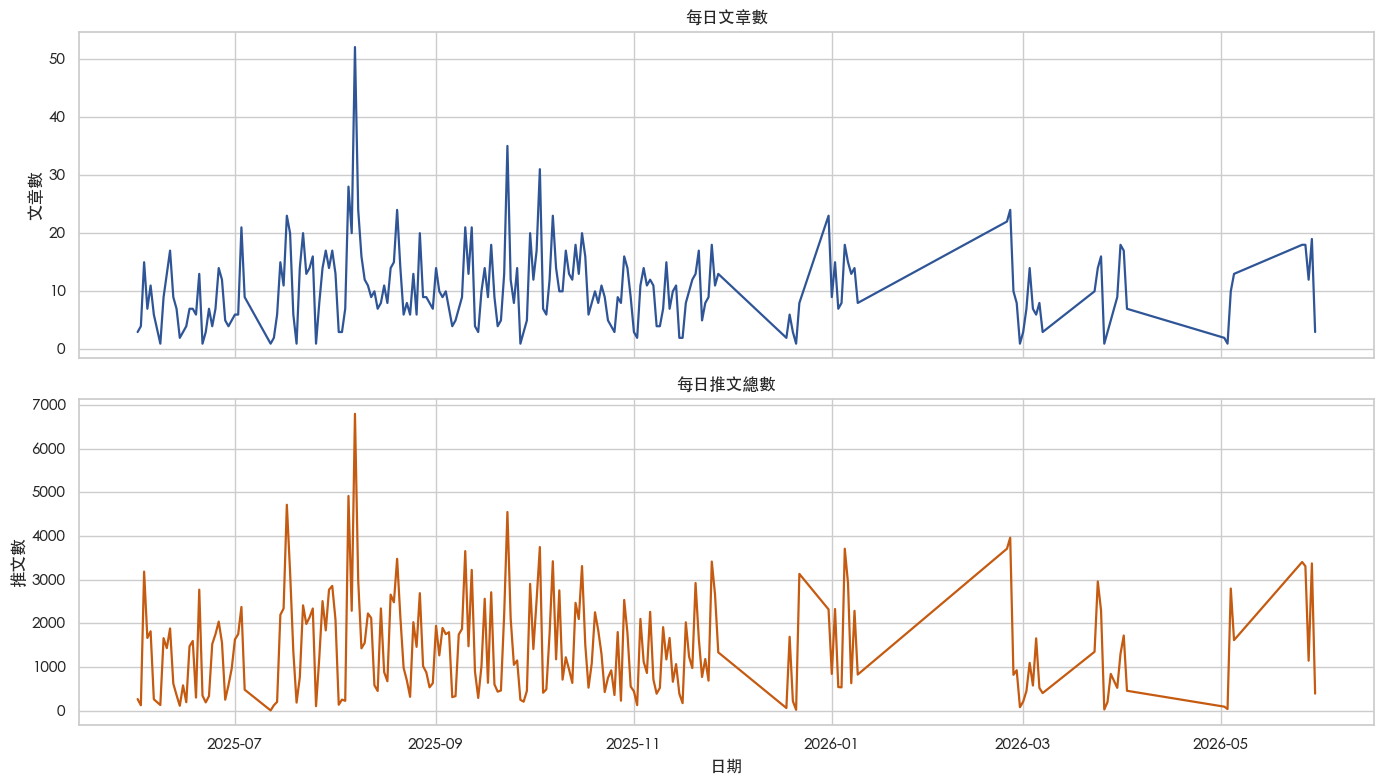

In [7]:
# 繪製每日文章量與推文量，找出討論熱度上升的期間。
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily['date'], daily['article_count'], color='#2F5597', linewidth=1.6)
axes[0].set_title('每日文章數')
axes[0].set_ylabel('文章數')

axes[1].plot(daily['date'], daily['comment_count'], color='#C55A11', linewidth=1.6)
axes[1].set_title('每日推文總數')
axes[1].set_ylabel('推文數')
axes[1].set_xlabel('日期')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'daily_articles_comments.png', dpi=180, bbox_inches='tight')
plt.show()

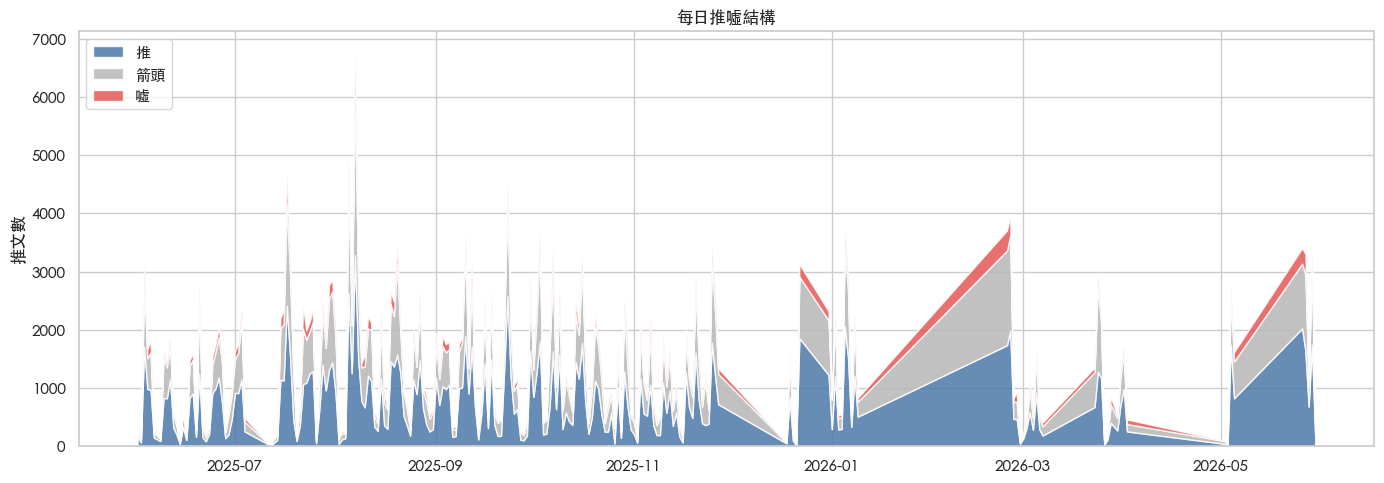

In [8]:
# 繪製推、噓、箭頭的每日堆疊面積圖，用來觀察互動型態是否有明顯轉變。
plot_daily = daily.set_index('date')[['push_count', 'neutral_count', 'boo_count']]
fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    plot_daily.index,
    plot_daily['push_count'],
    plot_daily['neutral_count'],
    plot_daily['boo_count'],
    labels=['推', '箭頭', '噓'],
    colors=['#4C78A8', '#B7B7B7', '#E45756'],
    alpha=0.85,
)
ax.set_title('每日推噓結構')
ax.set_ylabel('推文數')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'daily_comment_status_stack.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. PTT 文字清理與斷詞

In [9]:
# 建立 PTT 文章清理函式，移除網址、PTT 頁首資訊、簽名檔、控制字元與過多空白。
# 同時保留中文、英文與數字，因為台積電討論常包含 ADR、AI、NVIDIA、2nm 等關鍵詞。
def clean_ptt_text(text):
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'※\s*發信站:.*', ' ', text)
    text = re.sub(r'◆\s*From:.*', ' ', text)
    text = re.sub(r'--\s*\n.*', ' ', text, flags=re.S)
    text = re.sub(r'作者\s+\S+.*|標題\s+.*|時間\s+.*', ' ', text)
    text = re.sub(r'原文連結：|發布時間：|記者署名：|原文內容：|心得/評論：', ' ', text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'[^0-9A-Za-z\u4e00-\u9fff\s%\.\+\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 建立清理後的文章全文與標題文字，後續斷詞、TF-IDF、情緒與主題模型都使用這兩欄。
df['clean_title'] = df['artTitle'].map(clean_ptt_text)
df['clean_content'] = df['artContent'].map(clean_ptt_text)
df['clean_text'] = (df['clean_title'] + ' ' + df['clean_content']).str.strip()

# 推文也建立清理欄位，後續可比較文章與留言的語彙差異。
if len(comment_df) > 0:
    comment_df['clean_comment'] = comment_df['cmtContent'].map(clean_ptt_text)

display(df[['artTitle', 'clean_text']].head(3))

,artTitle,clean_text
0,[新聞]美股35年來最強5月表現後續看川普與就業,新聞 美股35年來最強5月表現後續看川普與就業 原文標題 美股35年來最強5月表現 後續看川...
1,[新聞]「大而美法案」可對外資課稅施俊吉：美關稅戰升級資本戰,新聞 大而美法案 可對外資課稅施俊吉 美關稅戰升級資本戰 原文標題 大而美法案 可對外資課稅...
2,[新聞]美國將中國部分產品的301關稅豁免延長至8,新聞 美國將中國部分產品的301關稅豁免延長至8 原文標題 美國將中國部分產品的301關稅豁...


In [10]:
# 載入停用字、繁中字典與財經自訂詞。
# 若 jieba 已安裝會使用 jieba；若沒有，會用字典最大匹配作為備援，確保 notebook 可繼續執行。
def read_word_file(path):
    if path is None or not Path(path).exists():
        return []
    text = Path(path).read_text(encoding='utf-8', errors='ignore')
    # LIWC 檔可能是一整行逗號分隔，停用字檔通常是一行一詞，因此同時支援逗號與換行。
    parts = re.split(r'[,\n\r\t]+', text)
    return [w.strip().lstrip('\ufeff') for w in parts if w.strip()]

stopwords = set()
if DICT_DIR is not None:
    stopwords.update(read_word_file(DICT_DIR / 'stopwords.txt'))
    stopwords.update(read_word_file(DICT_DIR / 'text_stopwords.txt'))

# 補充 PTT 與股票討論常見但分析意義較低的停用詞。
stopwords.update({
    '原文', '連結', '內容', '時間', '記者', '署名', '新聞', '標題', '心得', '評論',
    '可以', '不是', '就是', '真的', '一個', '今天', '明天', '昨天', '現在', '大家',
    '這個', '那個', '沒有', '可能', '因為', '所以', '如果', '還是', '一下', '以及',
    'ptt', 'html', 'www', 'com', 'https', 'http', 'stock', 'bbs'
})

# 針對 TSMC 與半導體議題補充自訂詞，避免重要詞被切得太碎。
finance_terms = {
    '台積電', 'TSMC', '台積電ADR', '半導體', '晶圓代工', '先進製程', 'CoWoS', 'AI',
    '輝達', 'NVIDIA', 'NVDA', '蘋果', 'Apple', 'AMD', '英特爾', 'Intel', '川普', '關稅',
    '美國', '中國', '台灣', '台股', '美股', '費半', 'ADR', '外資', '投信', '自營商',
    '法說會', '財報', '營收', '毛利率', 'EPS', '目標價', '看多', '看空', '利多', '利空',
    '漲停', '跌停', '多單', '空單', '多軍', '空軍', '2奈米', '3奈米', '5奈米', '封裝'
}

try:
    import jieba
    USE_JIEBA = True
    if DICT_DIR is not None and (DICT_DIR / 'dict.txt').exists():
        jieba.set_dictionary(str(DICT_DIR / 'dict.txt'))
    if DICT_DIR is not None and (DICT_DIR / 'user_dict.txt').exists():
        jieba.load_userdict(str(DICT_DIR / 'user_dict.txt'))
    for term in finance_terms:
        jieba.add_word(term)
    print('使用 jieba 斷詞。')
except Exception as exc:
    jieba = None
    USE_JIEBA = False
    print('未使用 jieba，改用內建字典最大匹配。原因：', exc)

# 建立備援字典；只保留長度 2 到 8 的詞，避免單字造成過多雜訊。
backup_dict = set(finance_terms)
if DICT_DIR is not None and (DICT_DIR / 'dict.txt').exists():
    for line in (DICT_DIR / 'dict.txt').read_text(encoding='utf-8', errors='ignore').splitlines():
        word = line.split(' ')[0].strip()
        if 2 <= len(word) <= 8:
            backup_dict.add(word)
MAX_BACKUP_WORD_LEN = max([len(w) for w in backup_dict] + [2])
print('停用字數：', len(stopwords), '備援字典詞數：', len(backup_dict))

Building prefix dict from /Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/dict/dict.txt ...
Dumping model to file cache /var/folders/dn/crq7pws16_zdbgt0gftcq5g00000gn/T/jieba.u7c504ef68651345b3eb506ba51dd4c68.cache
Loading model cost 0.181 seconds.
Prefix dict has been built successfully.


使用 jieba 斷詞。
停用字數： 1440 備援字典詞數： 304733


In [11]:
# 定義斷詞函式：中文使用 jieba 或最大匹配，英文與數字保留為 token。
# 斷詞後會移除停用字、單一中文字、過短英數字與純數字，降低雜訊。
def backup_cut_cjk(seq):
    tokens = []
    i = 0
    n = len(seq)
    while i < n:
        matched = None
        max_len = min(MAX_BACKUP_WORD_LEN, n - i)
        for L in range(max_len, 1, -1):
            cand = seq[i:i+L]
            if cand in backup_dict:
                matched = cand
                break
        if matched:
            tokens.append(matched)
            i += len(matched)
        else:
            # 單一中文字多半資訊量較低，因此預設略過。
            i += 1
    return tokens

def tokenize_text(text):
    text = clean_ptt_text(text)
    if USE_JIEBA:
        raw_tokens = list(jieba.cut(text))
    else:
        raw_tokens = []
        for part in re.findall(r'[A-Za-z]+|[0-9]+(?:\.[0-9]+)?|[\u4e00-\u9fff]+', text):
            if re.fullmatch(r'[\u4e00-\u9fff]+', part):
                raw_tokens.extend(backup_cut_cjk(part))
            else:
                raw_tokens.append(part)

    cleaned = []
    for token in raw_tokens:
        token = str(token).strip()
        if not token:
            continue
        token_lower = token.lower()
        if token in stopwords or token_lower in stopwords:
            continue
        if re.fullmatch(r'\d+(\.\d+)?', token):
            continue
        if re.fullmatch(r'[A-Za-z]', token):
            continue
        if len(token) < 2 and not re.fullmatch(r'[A-Za-z0-9]+', token):
            continue
        cleaned.append(token)
    return cleaned

# 先用少量文本檢查斷詞結果是否合理。
for text in df['clean_text'].head(3):
    print(tokenize_text(text)[:40])

['美股', '年來', '最強', '表現', '後續', '川普', '就業']
['大而美', '法案', '外資', '課稅', '施俊吉', '關稅', '升級', '資本']
['美國', '中國', '產品', '關稅', '豁免', '延長至']


In [12]:
# 對文章全文斷詞，建立 words 欄位與 article_word_df 長表。
# article_word_df 的格式便於計算詞頻、TF-IDF、情緒詞與共現網路。
df['tokens'] = df['clean_text'].map(tokenize_text)
df['words'] = df['tokens'].map(lambda xs: ' '.join(xs))
df['token_count'] = df['tokens'].map(len)

article_word_rows = []
for _, row in df[['system_id', 'artDate', 'date', 'artTitle', 'tokens']].iterrows():
    for pos, word in enumerate(row['tokens']):
        article_word_rows.append({
            'system_id': row['system_id'],
            'artDate': row['artDate'],
            'date': row['date'],
            'artTitle': row['artTitle'],
            'position': pos,
            'word': word,
        })
article_word_df = pd.DataFrame(article_word_rows)

print('文章 token 總數：', len(article_word_df))
display(df[['artTitle', 'token_count', 'words']].head())
article_word_df.to_csv(TABLE_DIR / 'article_word_table.csv', index=False, encoding='utf-8-sig')

文章 token 總數： 161248


,artTitle,token_count,words
0,[新聞]美股35年來最強5月表現後續看川普與就業,7,美股 年來 最強 表現 後續 川普 就業
1,[新聞]「大而美法案」可對外資課稅施俊吉：美關稅戰升級資本戰,8,大而美 法案 外資 課稅 施俊吉 關稅 升級 資本
2,[新聞]美國將中國部分產品的301關稅豁免延長至8,6,美國 中國 產品 關稅 豁免 延長至
3,[情報]2025/05/29（四）八大公股銀行買賣超?1,268,情報 八大 公股 銀行 買賣 來源 股網 網址 內文 以下 資訊 張數 排列 排名 股票 買...
4,[心得]台股現在在等美股大跌打第二隻腳,45,台股 美股 大跌 第二 輝達 財報 盤前 大漲 5% 台積電 沒漲 知道 慘啦 台股 跌破 ...


## 6. 詞頻、關鍵字與文字雲

In [13]:
# 計算全體文章的高頻詞，這是了解資料核心議題的第一步。
word_freq = article_word_df['word'].value_counts().reset_index()
word_freq.columns = ['word', 'count']
word_freq['ratio'] = word_freq['count'] / word_freq['count'].sum()

display(word_freq.head(30))
word_freq.to_csv(TABLE_DIR / 'article_word_frequency.csv', index=False, encoding='utf-8-sig')

,word,count,ratio
0,台積電,2807,0.017408
1,台灣,1418,0.008794
2,美國,1369,0.008490
3,投資,937,0.005811
4,關稅,898,0.005569
5,AI,804,0.004986
6,標的,803,0.004980
7,外資,750,0.004651
8,市場,673,0.004174
9,排行,671,0.004161


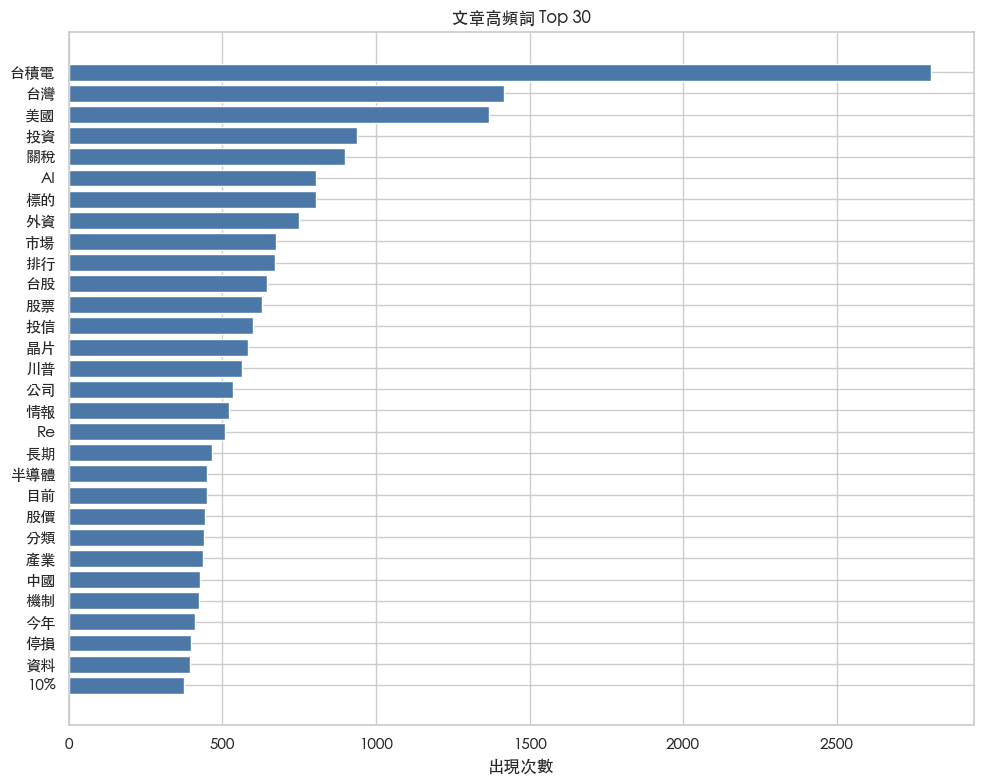

In [14]:
# 繪製前 30 個高頻詞長條圖，對應 Group 3 work 的詞頻視覺化方法。
top_n = 30
plot_df = word_freq.head(top_n).sort_values('count')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['word'], plot_df['count'], color='#4C78A8')
ax.set_title(f'文章高頻詞 Top {top_n}')
ax.set_xlabel('出現次數')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'top_article_words.png', dpi=180, bbox_inches='tight')
plt.show()

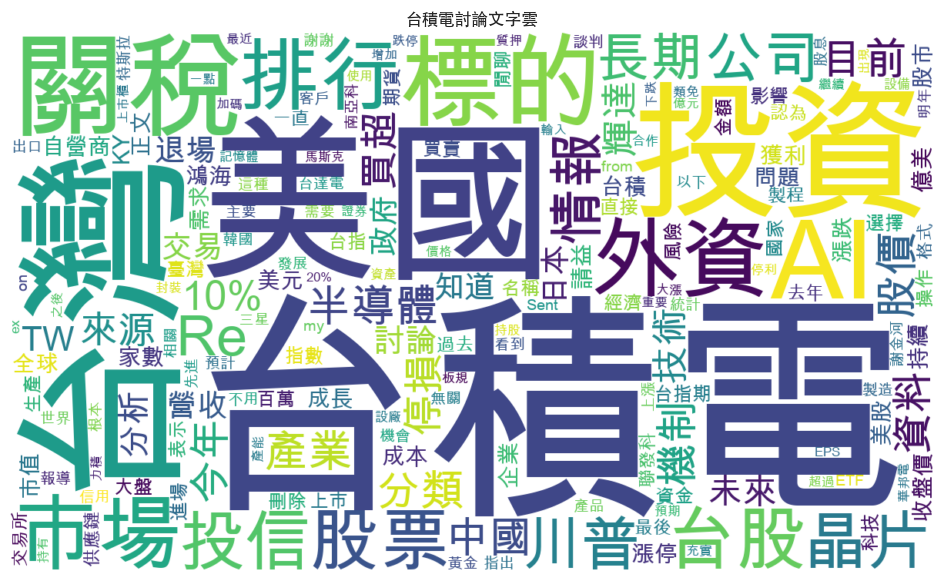

In [15]:
# 若環境有 wordcloud 套件，就產生文字雲；若沒有，略過但不影響後續分析。
try:
    from wordcloud import WordCloud
    font_candidates = [
        '/System/Library/Fonts/PingFang.ttc',
        '/Library/Fonts/Arial Unicode.ttf',
        'C:/Windows/Fonts/msjh.ttc',
    ]
    font_path = next((p for p in font_candidates if Path(p).exists()), None)
    wc = WordCloud(
        font_path=font_path,
        width=1200,
        height=700,
        background_color='white',
        max_words=180,
        colormap='viridis',
    ).generate_from_frequencies(dict(zip(word_freq['word'], word_freq['count'])))
    plt.figure(figsize=(12, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('台積電討論文字雲')
    plt.savefig(FIGURE_DIR / 'wordcloud_article_words.png', dpi=180, bbox_inches='tight')
    plt.show()
except Exception as exc:
    print('未產生文字雲；可安裝 wordcloud 後重跑。原因：', exc)

In [16]:
# 分析推文內容的高頻詞。推文量很大時抽樣可加速文字分析，但推噓數統計仍使用全量資料。
if len(comment_df) > 0:
    sample_size = min(len(comment_df), 80000)
    comment_sample = comment_df.sample(sample_size, random_state=42) if len(comment_df) > sample_size else comment_df.copy()
    comment_sample['tokens'] = comment_sample['clean_comment'].map(tokenize_text)
    comment_words = [w for tokens in comment_sample['tokens'] for w in tokens]
    comment_word_freq = pd.Series(comment_words).value_counts().reset_index()
    comment_word_freq.columns = ['word', 'count']
    display(comment_word_freq.head(30))
    comment_word_freq.to_csv(TABLE_DIR / 'comment_word_frequency_sample.csv', index=False, encoding='utf-8-sig')
else:
    comment_word_freq = pd.DataFrame(columns=['word', 'count'])
    print('沒有推文資料可分析。')

,word,count
0,美國,2044
1,台灣,1926
2,台積電,1677
3,台積,1280
4,知道,1186
5,GG,1121
6,外資,1105
7,台股,1082
8,一直,951
9,笑死,933


## 7. TF-IDF 關鍵詞分析

In [17]:
# 使用 TF-IDF 找出比單純詞頻更能代表文件差異的關鍵詞。
# tokenizer 已在前面完成，因此 TfidfVectorizer 直接以空白切分 words 欄位。
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

valid_docs = df[df['words'].str.len() > 0].copy()
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    min_df=3,
    max_df=0.85,
    max_features=2000,
)
doc_tfidf_matrix = tfidf_vectorizer.fit_transform(valid_docs['words'])
tfidf_terms = np.array(tfidf_vectorizer.get_feature_names_out())

# 以平均 TF-IDF 排名，找出全資料中最有代表性的詞。
avg_tfidf = np.asarray(doc_tfidf_matrix.mean(axis=0)).ravel()
tfidf_rank = pd.DataFrame({'word': tfidf_terms, 'avg_tfidf': avg_tfidf}).sort_values('avg_tfidf', ascending=False)
display(tfidf_rank.head(30))
tfidf_rank.to_csv(TABLE_DIR / 'tfidf_top_words.csv', index=False, encoding='utf-8-sig')

,word,avg_tfidf
841,情報,0.064174
511,台積電,0.055865
925,排行,0.047094
147,上市,0.039184
1696,買賣,0.039147
236,交易,0.037631
620,外資,0.036073
293,信用,0.035956
1441,統計,0.035443
899,投信,0.033856


In [18]:
# 對每篇文章取 TF-IDF 最高的前 10 個詞，方便後續做文章層級摘要。
def top_tfidf_terms_for_doc(row_idx, top_k=10):
    row = doc_tfidf_matrix[row_idx]
    if row.nnz == 0:
        return []
    pairs = sorted(zip(row.indices, row.data), key=lambda x: x[1], reverse=True)[:top_k]
    return [(tfidf_terms[i], round(float(v), 4)) for i, v in pairs]

article_keywords = []
for i, (_, row) in enumerate(valid_docs.iterrows()):
    article_keywords.append({
        'system_id': row['system_id'],
        'artDate': row['artDate'],
        'artTitle': row['artTitle'],
        'comment_count': row['comment_count'],
        'top_keywords': top_tfidf_terms_for_doc(i, top_k=10),
    })
article_keywords_df = pd.DataFrame(article_keywords)
display(article_keywords_df.sort_values('comment_count', ascending=False).head(10))
article_keywords_df.to_csv(TABLE_DIR / 'article_tfidf_keywords.csv', index=False, encoding='utf-8-sig')

,system_id,artDate,artTitle,comment_count,top_keywords
1830,1833,2025-12-22 08:30:00,[閒聊]2025/12/22盤中閒聊,1428,"[(古道, 0.285), (芳草, 0.285), (碧連天, 0.285), (天之涯,..."
291,292,2025-07-17 14:00:00,[閒聊]2025/07/17盤後閒聊,1425,"[(家數, 0.2726), (自營商, 0.2706), (ky, 0.2443), (1..."
470,471,2025-07-31 14:00:00,[閒聊]2025/07/31盤後閒聊,1424,"[(家數, 0.3503), (10%, 0.3033), (自營商, 0.2608), (..."
277,278,2025-07-16 14:00:00,[閒聊]2025/07/16盤後閒聊,1418,"[(家數, 0.2915), (南電, 0.2687), (10%, 0.2524), (古..."
1970,1973,2026-02-24 14:00:00,[閒聊]2026/02/24盤後閒聊,1417,"[(ky, 0.2902), (自營商, 0.241), (榮科, 0.2248), (華通..."
1999,2002,2026-02-25 14:00:25,[閒聊]2026/02/25盤後閒聊,1410,"[(ky, 0.3064), (自營商, 0.2546), (投信, 0.1859), (力..."
1465,1468,2025-10-20 14:00:02,[閒聊]2025/10/20盤後閒聊,1410,"[(家數, 0.3356), (10%, 0.2905), (自營商, 0.2498), (..."
371,372,2025-07-23 14:00:00,[閒聊]2025/07/23盤後閒聊,1408,"[(家數, 0.2717), (自營商, 0.2697), (精成科, 0.2493), (..."
2065,2068,2026-03-05 14:00:00,[閒聊]2026/03/05盤後閒聊,1408,"[(自營商, 0.273), (群創, 0.2277), (投信, 0.1993), (外資..."
1949,1952,2026-01-08 14:00:00,[閒聊]2026/01/08盤後閒聊,1408,"[(旺宏, 0.3286), (家數, 0.2755), (自營商, 0.2735), (1..."


## 8. LIWC 與財經詞典情緒分析

In [19]:
# 載入 LIWC 正負向詞表，並補上財經社群常見多空詞。
# 這裡採用詞典法，優點是可解釋；限制是反諷與語境可能無法完全判斷。
pos_words = set()
neg_words = set()
if DICT_DIR is not None:
    pos_words.update(read_word_file(DICT_DIR / 'liwc' / 'positive.txt'))
    neg_words.update(read_word_file(DICT_DIR / 'liwc' / 'negative.txt'))

stock_positive = {
    '利多', '看多', '買進', '上漲', '大漲', '噴出', '突破', '創高', '反彈', '成長',
    '強勢', '樂觀', '加碼', '升級', '獲利', '賺錢', '多軍', '漲停', '旺', '需求強'
}
stock_negative = {
    '利空', '看空', '賣出', '下跌', '大跌', '崩跌', '破底', '衰退', '悲觀', '降級',
    '虧損', '賠錢', '空軍', '跌停', '套牢', '風險', '砍單', '毛利率下滑', '關稅', '制裁'
}
pos_words.update(stock_positive)
neg_words.update(stock_negative)

print('正向詞數：', len(pos_words), '負向詞數：', len(neg_words))

正向詞數： 683 負向詞數： 1062


In [20]:
# 計算每篇文章的正向詞、負向詞與標準化情緒分數。
def sentiment_from_tokens(tokens):
    pos_count = sum(1 for w in tokens if w in pos_words)
    neg_count = sum(1 for w in tokens if w in neg_words)
    total = len(tokens) if len(tokens) > 0 else 1
    score = (pos_count - neg_count) / total
    return pd.Series({'pos_word_count': pos_count, 'neg_word_count': neg_count, 'lexicon_sentiment': score})

sentiment_features = df['tokens'].apply(sentiment_from_tokens)
df = pd.concat([df, sentiment_features], axis=1)

# 建立情緒分類標籤，便於做趨勢與表格摘要。
df['sentiment_label'] = pd.cut(
    df['lexicon_sentiment'],
    bins=[-np.inf, -0.002, 0.002, np.inf],
    labels=['負向', '中性', '正向']
)

display(df[['artTitle', 'pos_word_count', 'neg_word_count', 'lexicon_sentiment', 'sentiment_label', 'comment_count', 'net_push']].head(10))
display(df['sentiment_label'].value_counts().rename_axis('情緒標籤').reset_index(name='文章數'))

,artTitle,pos_word_count,neg_word_count,lexicon_sentiment,sentiment_label,comment_count,net_push
0,[新聞]美股35年來最強5月表現後續看川普與就業,0.0,0.0,0.000000,中性,20,2
1,[新聞]「大而美法案」可對外資課稅施俊吉：美關稅戰升級資本戰,1.0,1.0,0.000000,中性,96,57
2,[新聞]美國將中國部分產品的301關稅豁免延長至8,0.0,1.0,-0.166667,負向,148,81
3,[情報]2025/05/29（四）八大公股銀行買賣超?1,1.0,0.0,0.003731,正向,1,0
4,[心得]台股現在在等美股大跌打第二隻腳,1.0,3.0,-0.044444,負向,62,2
5,[心得]是產業傾向問題,1.0,2.0,-0.013699,負向,36,16
6,[情報]114年06月02日信用交易統計,0.0,0.0,0.000000,中性,23,16
7,[情報]2025/06/02（一）八大公股銀行買賣超排꘱,4.0,0.0,0.016667,正向,1,1
8,[新聞]輝達「地表最強超級電腦」要來了波若威,0.0,0.0,0.000000,中性,66,34
9,[新聞]直擊／台積電股東會前半小時湧人潮 勞,0.0,0.0,0.000000,中性,29,7


,情緒標籤,文章數
0,中性,990
1,正向,824
2,負向,465


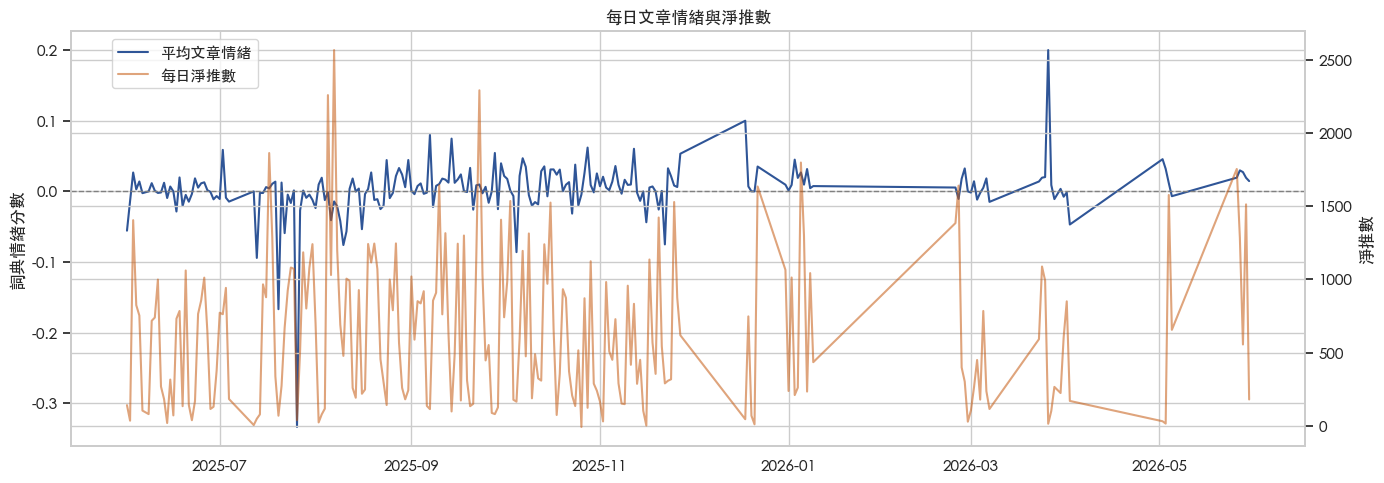

In [21]:
# 繪製每日平均詞典情緒與每日淨推數，比較文章語氣與互動回饋的走勢。
daily_sentiment = df.groupby('date', as_index=False).agg(
    avg_sentiment=('lexicon_sentiment', 'mean'),
    median_sentiment=('lexicon_sentiment', 'median'),
    article_count=('system_id', 'count'),
    net_push=('net_push', 'sum'),
)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily_sentiment['date'], daily_sentiment['avg_sentiment'], color='#2F5597', label='平均文章情緒')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel('詞典情緒分數')

ax2 = ax1.twinx()
ax2.plot(daily_sentiment['date'], daily_sentiment['net_push'], color='#C55A11', alpha=0.55, label='每日淨推數')
ax2.set_ylabel('淨推數')

ax1.set_title('每日文章情緒與淨推數')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'daily_sentiment_net_push.png', dpi=180, bbox_inches='tight')
plt.show()

daily_sentiment.to_csv(TABLE_DIR / 'daily_sentiment_summary.csv', index=False, encoding='utf-8-sig')

,正向詞,正向次數
0,成長,253
1,獲利,252
2,漲停,248
3,謝謝,149
4,上漲,142
5,大漲,131
6,加碼,123
7,重要,115
8,突破,112
9,買進,110


,負向詞,負向次數
0,關稅,898
1,問題,270
2,風險,195
3,跌停,122
4,下跌,116
5,套牢,79
6,壓力,78
7,大跌,76
8,賣出,71
9,降低,67


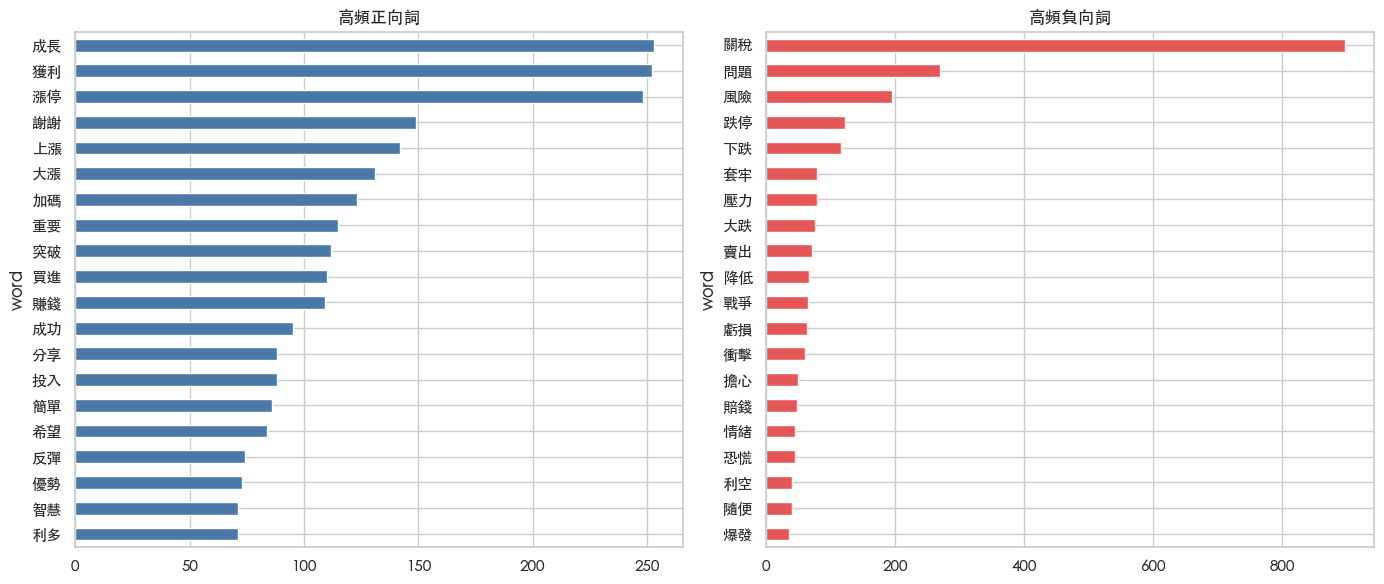

In [22]:
# 找出最常出現的正向詞與負向詞，了解多空討論使用哪些語彙。
sent_word_df = article_word_df.copy()
sent_word_df['sentiment'] = np.select(
    [sent_word_df['word'].isin(pos_words), sent_word_df['word'].isin(neg_words)],
    ['正向', '負向'],
    default='中性'
)

pos_top = sent_word_df[sent_word_df['sentiment'] == '正向']['word'].value_counts().head(20)
neg_top = sent_word_df[sent_word_df['sentiment'] == '負向']['word'].value_counts().head(20)

display(pd.DataFrame({'正向詞': pos_top.index, '正向次數': pos_top.values}))
display(pd.DataFrame({'負向詞': neg_top.index, '負向次數': neg_top.values}))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pos_top.sort_values().plot(kind='barh', ax=axes[0], color='#4C78A8', title='高頻正向詞')
neg_top.sort_values().plot(kind='barh', ax=axes[1], color='#E45756', title='高頻負向詞')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'top_sentiment_words.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Bigram / Trigram 與詞彙網路

In [23]:
# 產生 Bigram 與 Trigram，延續 Group 3 work2 透過 n-gram 補充斷詞與觀察固定詞組的做法。
def make_ngrams(tokens, n=2):
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

bigram_counter = Counter()
trigram_counter = Counter()
for tokens in df['tokens']:
    bigram_counter.update(make_ngrams(tokens, 2))
    trigram_counter.update(make_ngrams(tokens, 3))

bigram_df = pd.DataFrame(bigram_counter.most_common(100), columns=['bigram', 'count'])
trigram_df = pd.DataFrame(trigram_counter.most_common(100), columns=['trigram', 'count'])

display(bigram_df.head(30))
display(trigram_df.head(30))
bigram_df.to_csv(TABLE_DIR / 'top_bigrams.csv', index=False, encoding='utf-8-sig')
trigram_df.to_csv(TABLE_DIR / 'top_trigrams.csv', index=False, encoding='utf-8-sig')

,bigram,count
0,資料 來源,301
1,自營商 投信,275
2,投信 外資,275
3,家數 10%,274
4,退場 機制,273
5,長期 投資,238
6,分析 正文,221
7,排行 股票,208
8,股票 名稱,208
9,名稱 收盤價,208


,trigram,count
0,自營商 投信 外資,275
1,排行 股票 名稱,208
2,股票 名稱 收盤價,208
3,名稱 收盤價 漲跌,208
4,收盤價 漲跌 買超,208
5,漲跌 買超 百萬,208
6,台指期 自營商 投信,182
7,漲停 家數 10%,182
8,分類 分析 正文,163
9,情報 信用 交易,147


,word,degree_centrality
13,排行,0.121212
3,投信,0.106061
4,外資,0.106061
27,分類,0.075758
8,機制,0.060606
18,買超,0.060606
49,臺灣,0.060606
1,來源,0.060606
51,交易所,0.060606
2,自營商,0.045455


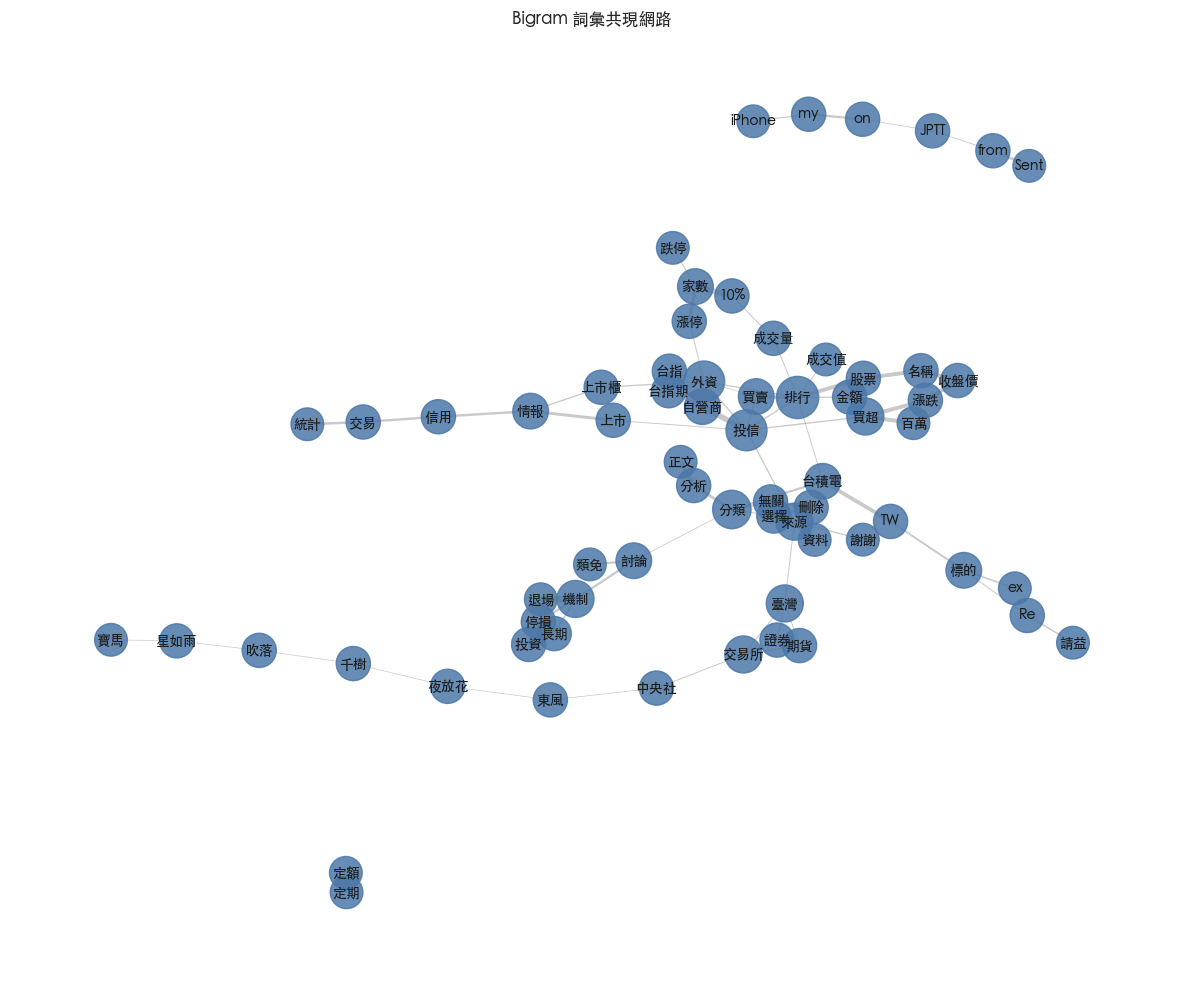

In [24]:
# 使用 Bigram 建立無向詞彙網路，節點代表詞，邊權重代表相鄰共現次數。
# 這可視為 Bigram network 的台積電版本。
import networkx as nx

G = nx.Graph()
for _, row in bigram_df.head(80).iterrows():
    parts = row['bigram'].split()
    if len(parts) != 2:
        continue
    a, b = parts
    if a == b:
        continue
    G.add_edge(a, b, weight=int(row['count']))

centrality = nx.degree_centrality(G) if G.number_of_nodes() else {}
centrality_df = pd.DataFrame({
    'word': list(centrality.keys()),
    'degree_centrality': list(centrality.values()),
}).sort_values('degree_centrality', ascending=False)

display(centrality_df.head(20))
centrality_df.to_csv(TABLE_DIR / 'bigram_network_centrality.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 10))
if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, seed=42, k=0.55)
    weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
    widths = 0.5 + 4 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
    node_sizes = [500 + 3500 * centrality.get(n, 0) for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.35, edge_color='#666666', ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C78A8', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
ax.set_title('Bigram 詞彙共現網路')
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'bigram_network.png', dpi=180, bbox_inches='tight')
plt.show()

## 10. 詞彙相關與共現分析

In [25]:
# 建立文件詞頻矩陣 DTM，並計算高頻詞之間的文件層級相關性。
# 這對應 pairwise correlation 方法。
count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    min_df=5,
    max_df=0.8,
    max_features=800,
)
dtm = count_vectorizer.fit_transform(valid_docs['words'])
dtm_terms = np.array(count_vectorizer.get_feature_names_out())
dtm_df = pd.DataFrame(dtm.toarray(), columns=dtm_terms, index=valid_docs['system_id'])

# 只取總詞頻前 80 的詞計算相關，避免矩陣過大且雜訊太多。
top_terms = dtm_df.sum().sort_values(ascending=False).head(80).index.tolist()
cor_df = dtm_df[top_terms].corr().fillna(0)

display(cor_df.iloc[:10, :10])
cor_df.to_csv(TABLE_DIR / 'top_word_correlation_matrix.csv', encoding='utf-8-sig')

,台積電,台灣,美國,投資,關稅,ai,標的,外資,市場,排行
台積電,1.000000,0.256029,0.220933,0.208544,0.144154,0.229110,0.085879,0.017078,0.171211,-0.080588
台灣,0.256029,1.000000,0.493425,0.276752,0.491241,0.136912,-0.073133,0.018635,0.249969,-0.072578
美國,0.220933,0.493425,1.000000,0.416574,0.523767,0.159739,-0.054246,-0.021267,0.244105,-0.091245
投資,0.208544,0.276752,0.416574,1.000000,0.262236,0.123542,0.186186,-0.041182,0.232873,-0.107732
關稅,0.144154,0.491241,0.523767,0.262236,1.000000,-0.008197,-0.042641,0.003745,0.165127,-0.082396
ai,0.229110,0.136912,0.159739,0.123542,-0.008197,1.000000,0.007346,-0.018504,0.228705,-0.080276
標的,0.085879,-0.073133,-0.054246,0.186186,-0.042641,0.007346,1.000000,-0.056710,0.218305,-0.139763
外資,0.017078,0.018635,-0.021267,-0.041182,0.003745,-0.018504,-0.056710,1.000000,0.038678,0.682323
市場,0.171211,0.249969,0.244105,0.232873,0.165127,0.228705,0.218305,0.038678,1.000000,-0.088301
排行,-0.080588,-0.072578,-0.091245,-0.107732,-0.082396,-0.080276,-0.139763,0.682323,-0.088301,1.000000


In [26]:
# 定義查詢特定詞彙相關詞的函式，可用來檢查「台積電」、「關稅」、「輝達」等詞的語境關聯。
def get_top_correlations(target_word, n=12):
    if target_word not in cor_df.columns:
        print(f'「{target_word}」不在目前 DTM 特徵中。')
        return pd.DataFrame(columns=['word', 'correlation'])
    result = cor_df[target_word].drop(target_word).sort_values(ascending=False).head(n)
    return result.reset_index().rename(columns={'index': 'word', target_word: 'correlation'})

for target in ['台積電', '關稅', '輝達', '美國', '中國', 'AI']:
    print('\n相關詞：', target)
    display(get_top_correlations(target, n=10))


相關詞： 台積電


,word,correlation
0,技術,0.307965
1,需求,0.274618
2,未來,0.268533
3,產業,0.262032
4,台灣,0.256029
5,影響,0.238996
6,全球,0.238723
7,ai,0.229110
8,美國,0.220933
9,半導體,0.217243



相關詞： 關稅


,word,correlation
0,川普,0.584047
1,美國,0.523767
2,台灣,0.491241
3,政府,0.422055
4,影響,0.406066
5,半導體,0.401173
6,日本,0.399154
7,產業,0.281468
8,投資,0.262236
9,億美,0.235844



相關詞： 輝達


...

,word,correlation
0,川普,0.566315
1,關稅,0.523767
2,台灣,0.493425
3,中國,0.457202
4,政府,0.419480
5,投資,0.416574
6,半導體,0.361821
7,晶片,0.335700
8,企業,0.296168
9,億美,0.291448



相關詞： 中國


,word,correlation
0,晶片,0.489663
1,美國,0.457202
2,輝達,0.376794
3,ai,0.264240
4,企業,0.233560
5,川普,0.223465
6,台灣,0.221256
7,目前,0.190108
8,技術,0.184142
9,政府,0.169909



相關詞： AI
「AI」不在目前 DTM 特徵中。


,word,correlation


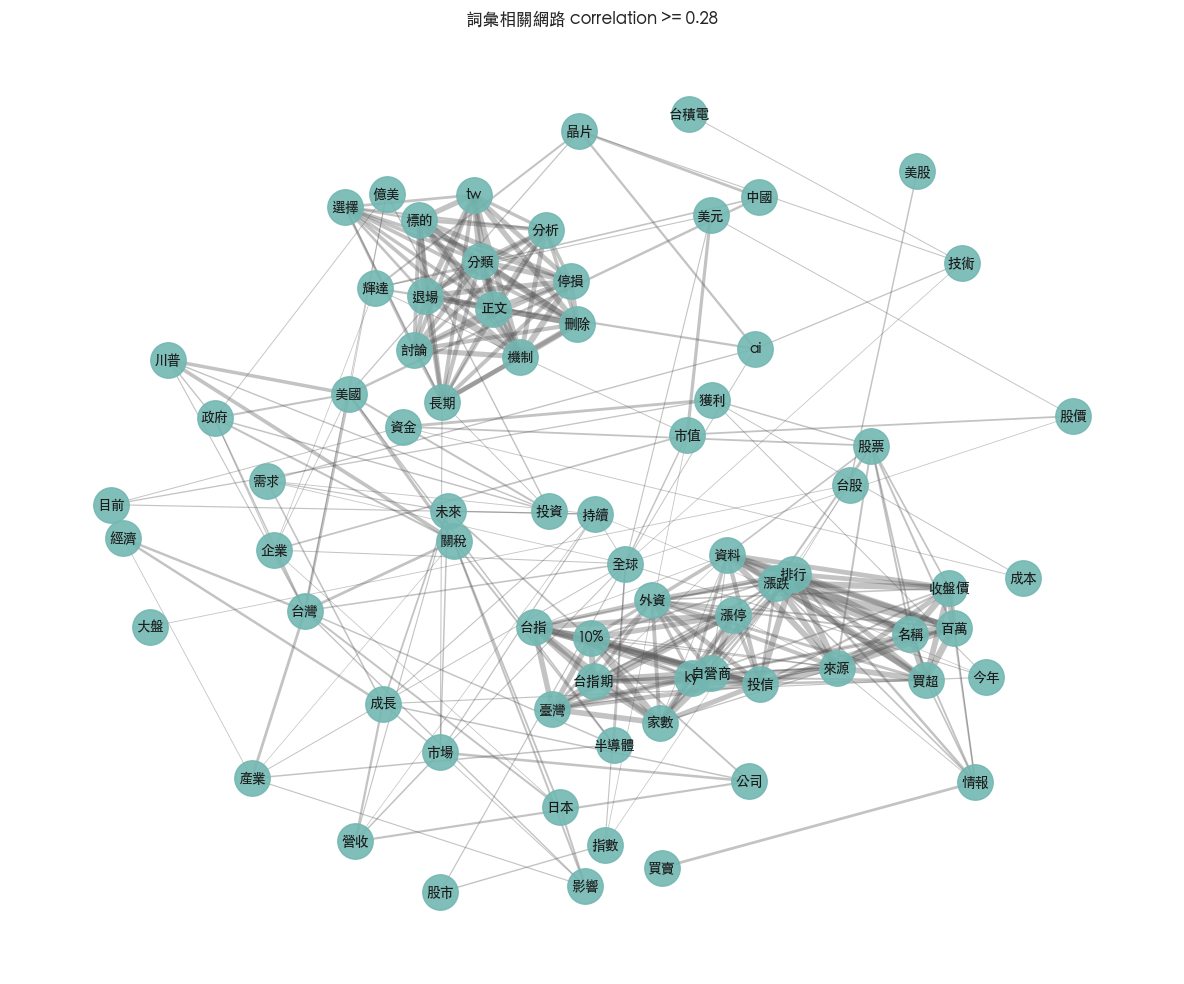

In [27]:
# 將高相關詞對畫成網路圖；邊代表兩個詞在文章層級上常一起出現。
threshold = 0.28
corr_graph = nx.Graph()
for i, w1 in enumerate(top_terms):
    for w2 in top_terms[i+1:]:
        corr = float(cor_df.loc[w1, w2])
        if corr >= threshold:
            corr_graph.add_edge(w1, w2, weight=corr)

fig, ax = plt.subplots(figsize=(12, 10))
if corr_graph.number_of_nodes() > 0:
    pos = nx.spring_layout(corr_graph, seed=42, k=0.65)
    weights = np.array([corr_graph[u][v]['weight'] for u, v in corr_graph.edges()])
    widths = 0.5 + 5 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
    nx.draw_networkx_edges(corr_graph, pos, width=widths, alpha=0.35, edge_color='#555555', ax=ax)
    nx.draw_networkx_nodes(corr_graph, pos, node_size=650, node_color='#72B7B2', alpha=0.9, ax=ax)
    nx.draw_networkx_labels(corr_graph, pos, font_size=10, ax=ax)
    ax.set_title(f'詞彙相關網路 correlation >= {threshold}')
else:
    ax.text(0.5, 0.5, '沒有達到門檻的詞對，可降低 threshold。', ha='center', va='center')
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'word_correlation_network.png', dpi=180, bbox_inches='tight')
plt.show()

## 11. 文章相似度分析

In [28]:
# 使用 TF-IDF cosine similarity 找出相似文章，對應 Group 3 work2 的文章相似度方法。
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(doc_tfidf_matrix)
valid_docs = valid_docs.reset_index(drop=True)

def find_similar_articles(query_idx=0, top_k=8):
    if query_idx < 0 or query_idx >= len(valid_docs):
        raise IndexError('query_idx 超出 valid_docs 範圍。')
    sims = cosine_sim[query_idx]
    top_indices = np.argsort(sims)[::-1][1:top_k+1]
    result = valid_docs.loc[top_indices, ['system_id', 'artDate', 'artTitle', 'comment_count', 'artUrl']].copy()
    result['similarity'] = sims[top_indices]
    result.insert(0, 'query_title', valid_docs.loc[query_idx, 'artTitle'])
    return result

# 預設以推文最多的文章當查詢文章，觀察哪些文章語意最接近。
query_idx = int(valid_docs['comment_count'].idxmax()) if len(valid_docs) else 0
similar_articles = find_similar_articles(query_idx=query_idx, top_k=10)
display(similar_articles)
similar_articles.to_csv(TABLE_DIR / 'similar_articles_for_top_comment_article.csv', index=False, encoding='utf-8-sig')

,query_title,system_id,artDate,artTitle,comment_count,artUrl,similarity
112,[閒聊]2025/12/22盤中閒聊,113,2025-06-17 14:00:00,[閒聊]2025/06/17盤後閒聊,789,https://www.ptt.cc/bbs/Stock/M.1750140003.A.44...,0.722236
60,[閒聊]2025/12/22盤中閒聊,61,2025-06-10 14:01:31,[閒聊]2025/06/10盤後閒聊,206,https://www.ptt.cc/bbs/Stock/M.1749535294.A.86...,0.703282
161,[閒聊]2025/12/22盤中閒聊,162,2025-06-25 14:00:17,[閒聊]2025/06/25盤後閒聊,1377,https://www.ptt.cc/bbs/Stock/M.1750831222.A.D1...,0.696241
15,[閒聊]2025/12/22盤中閒聊,16,2025-06-03 14:00:01,[閒聊]2025/06/03盤後閒聊,1368,https://www.ptt.cc/bbs/Stock/M.1748930404.A.1B...,0.686303
2163,[閒聊]2025/12/22盤中閒聊,2166,2026-04-01 14:00:00,[閒聊]2026/04/01盤後閒聊,1011,https://www.ptt.cc/bbs/Stock/M.1775023202.A.1C...,0.682545
121,[閒聊]2025/12/22盤中閒聊,122,2025-06-18 14:02:03,[閒聊]2025/06/18盤後閒聊,1381,https://www.ptt.cc/bbs/Stock/M.1750226526.A.F7...,0.678668
277,[閒聊]2025/12/22盤中閒聊,278,2025-07-16 14:00:00,[閒聊]2025/07/16盤後閒聊,1418,https://www.ptt.cc/bbs/Stock/M.1752645603.A.AE...,0.677899
265,[閒聊]2025/12/22盤中閒聊,266,2025-07-15 14:00:46,[閒聊]2025/07/15盤後閒聊,1202,https://www.ptt.cc/bbs/Stock/M.1752559249.A.9F...,0.649785
49,[閒聊]2025/12/22盤中閒聊,50,2025-06-09 14:00:42,[閒聊]2025/06/09盤後閒聊,1381,https://www.ptt.cc/bbs/Stock/M.1749448847.A.FF...,0.283210
2095,[閒聊]2025/12/22盤中閒聊,2098,2026-03-24 14:00:00,[閒聊]2026/03/24盤後閒聊,1350,https://www.ptt.cc/bbs/Stock/M.1774332003.A.11...,0.273228


## 12. LDA 主題模型

In [29]:
# 使用 sklearn LDA 進行主題模型，作為較輕量、可離線執行的 topic modeling。
# 這裡不使用 BERTopic，因為它需要額外大型模型與套件，對一般作業環境較重。
from sklearn.decomposition import LatentDirichletAllocation

lda_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    min_df=5,
    max_df=0.75,
    max_features=1500,
)
lda_X = lda_vectorizer.fit_transform(valid_docs['words'])
lda_terms = np.array(lda_vectorizer.get_feature_names_out())

n_topics = 6
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method='batch',
    random_state=42,
    max_iter=20,
)
lda_doc_topic = lda_model.fit_transform(lda_X)

# 整理每個主題的代表詞。
topic_rows = []
for topic_idx, comp in enumerate(lda_model.components_):
    top_idx = comp.argsort()[::-1][:15]
    topic_rows.append({
        'topic': topic_idx,
        'top_words': '、'.join(lda_terms[top_idx]),
    })
topic_df = pd.DataFrame(topic_rows)
display(topic_df)
topic_df.to_csv(TABLE_DIR / 'lda_topics.csv', index=False, encoding='utf-8-sig')

,topic,top_words
0,0,美國、台積電、台灣、關稅、ai、晶片、川普、半導體、投資、中國、產業、公司、技術、政府、市場
1,1,標的、分類、機制、停損、長期、tw、退場、討論、台積電、分析、投資、正文、刪除、格式、選擇
2,2,排行、外資、買超、情報、投信、收盤價、資料、股票、來源、百萬、漲跌、名稱、買賣、上市、台積電
3,3,自營商、外資、10%、家數、投信、台指、漲停、臺灣、台指期、閒聊、交易所、排行、ky、櫃買、成交量
4,4,台積電、台股、股價、市值、投資、市場、ai、美股、指數、股市、今年、股票、獲利、大盤、美元
5,5,台積電、股票、操作、re、標的、sent、from、on、my、股息、知道、請益、台灣、股價、定期


,topic,top_words,artDate,artTitle,comment_count,push_ratio
0,0,美國、台積電、台灣、關稅、ai、晶片、川普、半導體、投資、中國、產業、公司、技術、政府、市場,2025-08-05 20:50:16,[新聞]獨家》台積電2奈米機密外洩案災情慘重上,976,0.502049
1,0,美國、台積電、台灣、關稅、ai、晶片、川普、半導體、投資、中國、產業、公司、技術、政府、市場,2025-08-08 21:31:20,[新聞]台灣關稅不只20％經貿辦證實:暫時性關,900,0.466667
2,0,美國、台積電、台灣、關稅、ai、晶片、川普、半導體、投資、中國、產業、公司、技術、政府、市場,2025-11-23 12:12:46,Re:[新聞]輝達內部會議大吐苦水！黃仁勳：怎麼做,858,0.265734
3,0,美國、台積電、台灣、關稅、ai、晶片、川普、半導體、投資、中國、產業、公司、技術、政府、市場,2025-08-01 07:23:28,[新聞]快訊／川普宣布：台灣對等關稅稅率20％,794,0.511335
4,0,美國、台積電、台灣、關稅、ai、晶片、川普、半導體、投資、中國、產業、公司、技術、政府、市場,2025-11-25 18:05:37,[新聞]台積電正式提告羅唯仁公司完整聲明來了,701,0.437946
5,1,標的、分類、機制、停損、長期、tw、退場、討論、台積電、分析、投資、正文、刪除、格式、選擇,2026-05-26 22:07:21,[標的]台指期44444空,571,0.767075
6,1,標的、分類、機制、停損、長期、tw、退場、討論、台積電、分析、投資、正文、刪除、格式、選擇,2026-05-04 11:07:29,[標的]台指空菁英空軍大集合,562,0.779359
7,1,標的、分類、機制、停損、長期、tw、退場、討論、台積電、分析、投資、正文、刪除、格式、選擇,2026-03-23 19:22:37,[標的]小台04空,487,0.770021
8,1,標的、分類、機制、停損、長期、tw、退場、討論、台積電、分析、投資、正文、刪除、格式、選擇,2026-01-05 12:29:25,[標的]台指期空,417,0.726619
9,1,標的、分類、機制、停損、長期、tw、退場、討論、台積電、分析、投資、正文、刪除、格式、選擇,2025-08-08 10:48:34,[標的]大盤假突破空,398,0.781407


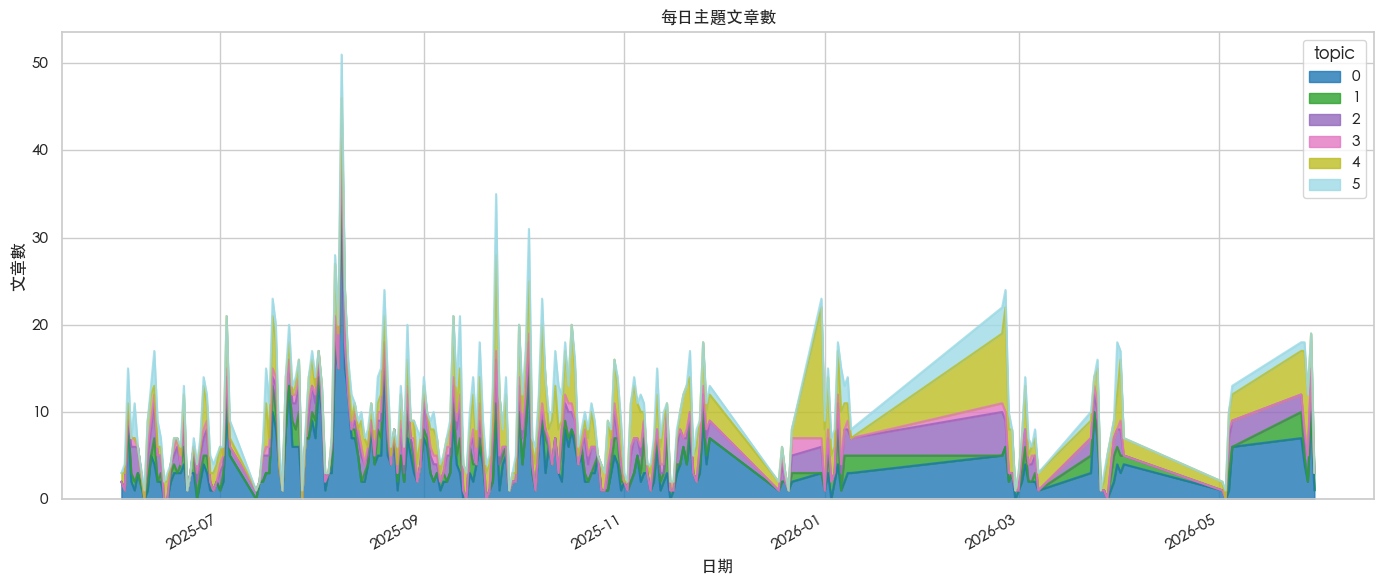

In [30]:
# 將每篇文章指派到機率最高的主題，並觀察主題在時間上的變化。
doc_topic_df = valid_docs[['system_id', 'artDate', 'date', 'artTitle', 'comment_count', 'push_ratio']].copy()
doc_topic_df['topic'] = lda_doc_topic.argmax(axis=1)
doc_topic_df['topic_prob'] = lda_doc_topic.max(axis=1)

# 每個主題挑出互動最高的代表文章。
representative_articles = (
    doc_topic_df.sort_values(['topic', 'comment_count'], ascending=[True, False])
    .groupby('topic')
    .head(5)
    .merge(topic_df, on='topic', how='left')
)
display(representative_articles[['topic', 'top_words', 'artDate', 'artTitle', 'comment_count', 'push_ratio']])

topic_daily = doc_topic_df.groupby(['date', 'topic'], as_index=False).size().rename(columns={'size': 'article_count'})
topic_daily['date'] = pd.to_datetime(topic_daily['date'])
topic_pivot = topic_daily.pivot(index='date', columns='topic', values='article_count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
topic_pivot.plot(kind='area', stacked=True, alpha=0.8, ax=ax, colormap='tab20')
ax.set_title('每日主題文章數')
ax.set_ylabel('文章數')
ax.set_xlabel('日期')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'lda_topic_trend.png', dpi=180, bbox_inches='tight')
plt.show()

doc_topic_df.to_csv(TABLE_DIR / 'article_lda_topic_assignment.csv', index=False, encoding='utf-8-sig')

## 13. 高互動文章分類模型

In [31]:
# 原始 artCatagory 全部是 Stock，因此不做無意義的看板分類。
# 這裡改用 Group 3 work2 week7 的分類流程，預測文章是否屬於推文數前 25% 的高互動文章。
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model_df = df[df['words'].str.len() > 0].copy()
threshold_comments = model_df['comment_count'].quantile(0.75)
model_df['high_engagement'] = (model_df['comment_count'] >= threshold_comments).astype(int)

print('高互動門檻 comment_count >=', threshold_comments)
display(model_df['high_engagement'].value_counts().rename_axis('high_engagement').reset_index(name='文章數'))

高互動門檻 comment_count >= 122.0


,high_engagement,文章數
0,0,1704
1,1,573


In [32]:
# 切分訓練集與測試集，並建立 TF-IDF + Logistic Regression pipeline。
# Logistic Regression 的係數可解釋哪些詞較容易推向高互動或低互動。
X = model_df['words']
y = model_df['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ('tfidf', TfidfVectorizer(tokenizer=str.split, token_pattern=None, min_df=3, max_df=0.85, max_features=2000)),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1')
print('5-fold F1：', np.round(cv_scores, 4), '平均：', round(cv_scores.mean(), 4))

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['一般互動', '高互動']))

5-fold F1： [0.4639 0.5137 0.5076 0.4889 0.5825] 平均： 0.5113
              precision    recall  f1-score   support

        一般互動       0.83      0.80      0.81       427
         高互動       0.46      0.52      0.49       143

    accuracy                           0.73       570
   macro avg       0.65      0.66      0.65       570
weighted avg       0.74      0.73      0.73       570



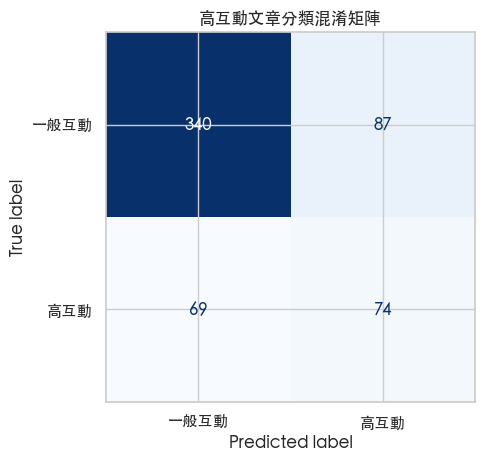

In [33]:
# 繪製混淆矩陣，觀察模型對一般互動與高互動文章的辨識狀況。
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['一般互動', '高互動'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('高互動文章分類混淆矩陣')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'high_engagement_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

,word,coef
633,外資,1.639066
519,台灣,1.559665
704,家數,1.550107
5,10%,1.485986
1539,自營商,1.336084
592,國安,1.267277
1883,閒聊,1.240116
1571,萬元,1.187330
1370,示警,1.168411
840,快訊,1.152650


,word,coef
100,re,-3.299460
904,投信,-2.464370
846,情報,-1.893918
1695,買超,-1.817117
1448,統計,-1.668275
301,信用,-1.565165
373,公司,-1.338628
979,收盤價,-1.213523
34,ai,-1.204700
241,交易,-1.151629


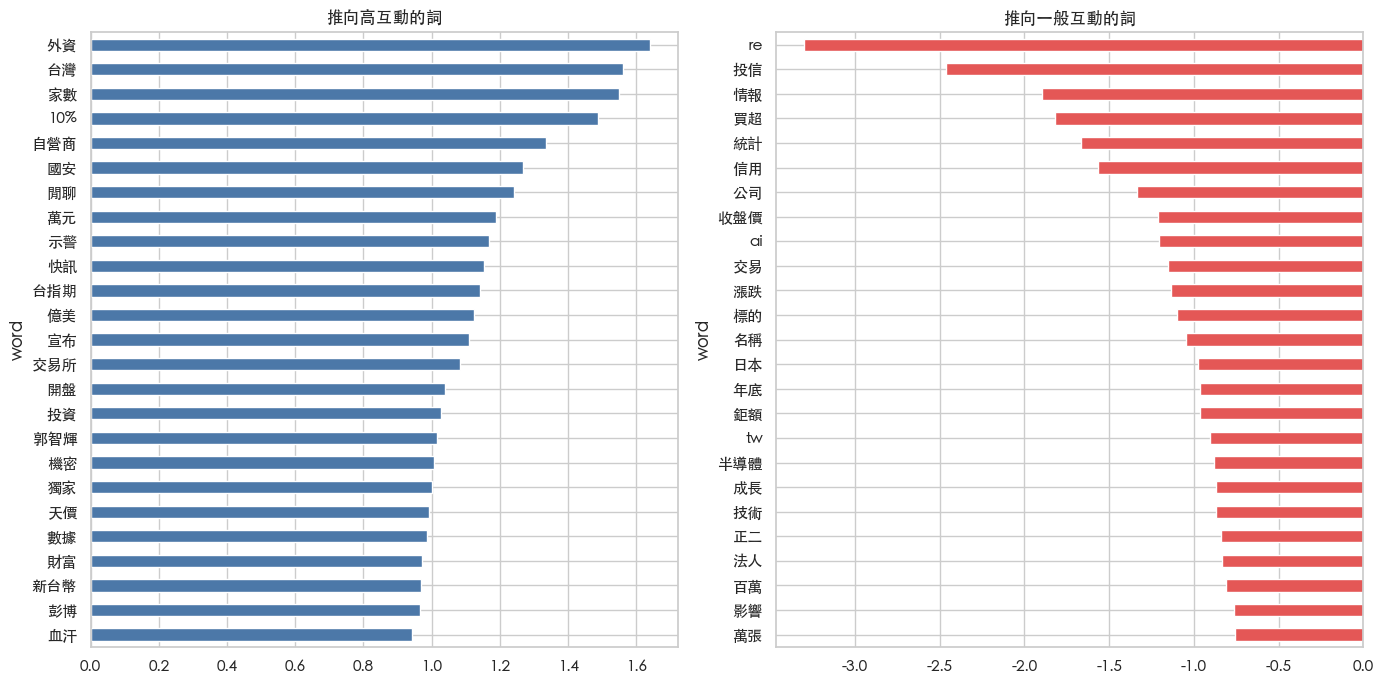

In [34]:
# 萃取 Logistic Regression 係數，找出最能區分高互動與一般互動的詞。
tfidf_step = clf.named_steps['tfidf']
lr_step = clf.named_steps['lr']
feature_names = np.array(tfidf_step.get_feature_names_out())
coef = lr_step.coef_[0]

coef_df = pd.DataFrame({'word': feature_names, 'coef': coef}).sort_values('coef', ascending=False)
high_words = coef_df.head(25)
low_words = coef_df.tail(25).sort_values('coef')

display(high_words)
display(low_words)
coef_df.to_csv(TABLE_DIR / 'high_engagement_logistic_coefficients.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
high_words.sort_values('coef').plot(kind='barh', x='word', y='coef', ax=axes[0], color='#4C78A8', legend=False, title='推向高互動的詞')
low_words.sort_values('coef', ascending=False).plot(kind='barh', x='word', y='coef', ax=axes[1], color='#E45756', legend=False, title='推向一般互動的詞')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'high_engagement_coefficients.png', dpi=180, bbox_inches='tight')
plt.show()

## 14. 可選：Word2Vec 詞向量分析


相似詞： 台積電


,word,similarity
0,歸來,0.445565
1,一千五百多,0.434754
2,世芯,0.433462
3,多久,0.429258
4,美積電,0.428706
5,群聯,0.427963
6,翻車,0.426060
7,發佈,0.421916
8,引起,0.421802
9,資本,0.416602



相似詞： TSMC


,word,similarity
0,ADR,0.657227
1,AVGO,0.614493
2,Broadcom,0.585487
3,Hynix,0.585391
4,AMD,0.578803
5,cuda,0.573253
6,18A,0.572035
7,TSM,0.563005
8,more,0.562915
9,笑話,0.562691



相似詞： 關稅


...

,word,similarity
0,NVIDIA,0.604646
1,H20,0.541565
2,Nvidia,0.515589
3,ARM,0.503762
4,超微,0.498503
5,夜市,0.487763
6,GPU,0.485029
7,卡關,0.484904
8,北士科,0.483238
9,陳其邁,0.482267



相似詞： 美國


,word,similarity
0,對台,0.572746
1,出口到,0.569520
2,零關稅,0.560495
3,川普,0.555912
4,加拿大,0.555657
5,免除,0.554510
6,逼迫,0.549615
7,賓士,0.545675
8,加徵,0.541942
9,拜登,0.537352



相似詞： AI


,word,similarity
0,硬體,0.578577
1,算力,0.578415
2,Open,0.574193
3,雲端,0.555791
4,google,0.540128
5,效能,0.537902
6,基石,0.516437
7,蓬勃,0.506949
8,自有,0.505171
9,NVIDIA,0.503006


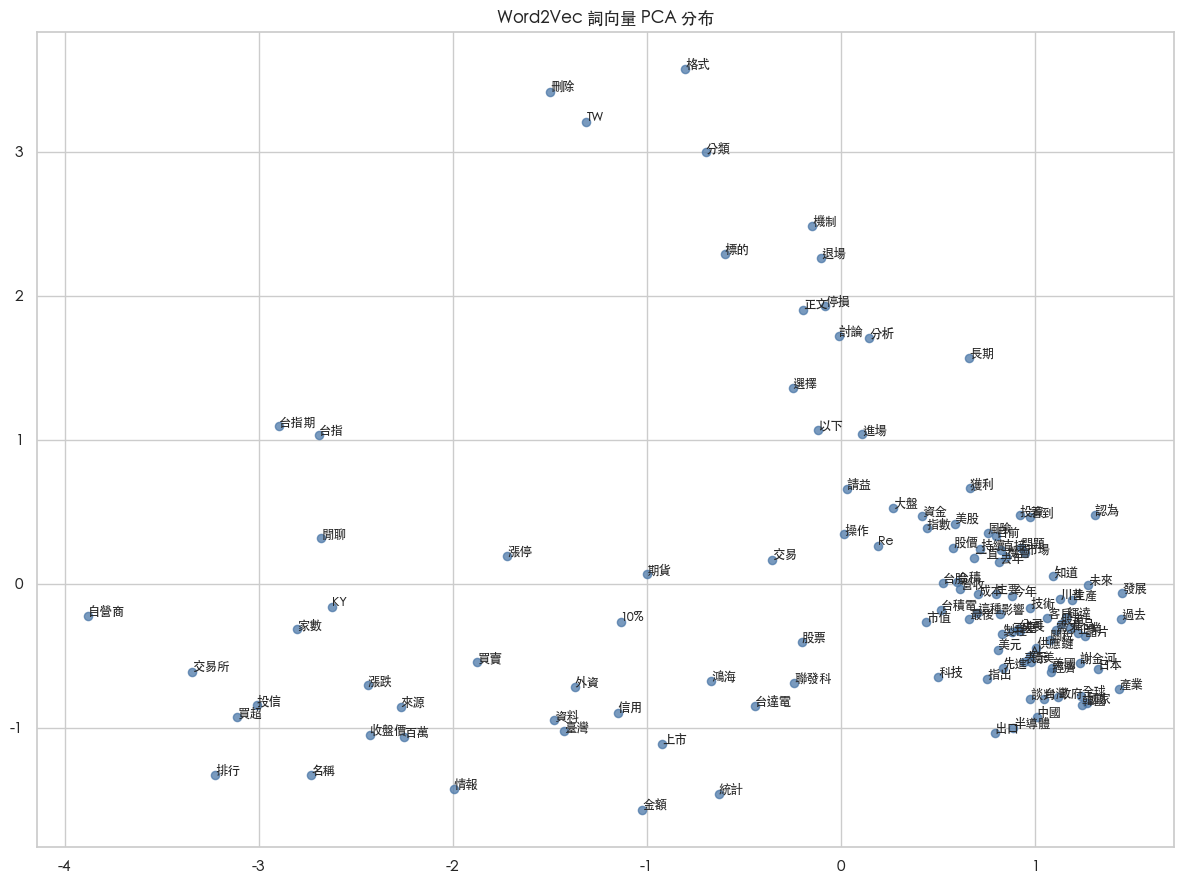

In [35]:
# 這段對應 Word2Vec 概念。
# 若環境沒有 gensim，會直接略過；若有，會訓練台積電語料的詞向量並列出相似詞。
try:
    from gensim.models import Word2Vec
    from sklearn.decomposition import PCA

    sentences = [tokens for tokens in df['tokens'] if len(tokens) >= 3]
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=5,
        workers=2,
        sg=1,
        seed=42,
        epochs=20,
    )

    query_terms = [w for w in ['台積電', 'TSMC', '關稅', '輝達', '美國', 'AI'] if w in w2v_model.wv]
    for term in query_terms:
        print('\n相似詞：', term)
        display(pd.DataFrame(w2v_model.wv.most_similar(term, topn=10), columns=['word', 'similarity']))

    # 將高頻詞向量降到 2 維，畫出詞向量空間分布。
    #vocab = [w for w, _ in word_freq.head(120).values if w in w2v_model.wv]
    vocab = [w for w in word_freq.head(120)['word'] if w in w2v_model.wv]
    if len(vocab) >= 5:
        vecs = np.vstack([w2v_model.wv[w] for w in vocab])
        coords = PCA(n_components=2, random_state=42).fit_transform(vecs)
        emb_df = pd.DataFrame({'word': vocab, 'x': coords[:, 0], 'y': coords[:, 1]})
        fig, ax = plt.subplots(figsize=(12, 9))
        ax.scatter(emb_df['x'], emb_df['y'], s=35, color='#4C78A8', alpha=0.75)
        for _, r in emb_df.iterrows():
            ax.text(r['x'], r['y'], r['word'], fontsize=9)
        ax.set_title('Word2Vec 詞向量 PCA 分布')
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / 'word2vec_pca.png', dpi=180, bbox_inches='tight')
        plt.show()
except Exception as exc:
    print('略過 Word2Vec；若要執行請安裝 gensim。原因：', exc)

## 15. 社群網路分析：發文者與留言者

這一段加入中文社群網路分析的核心方法：把推文者視為來源節點、發文者視為目標節點，依推/噓/箭頭轉成加權邊，建立 PTT 使用者互動網路。後續會計算 Eigenvector、PageRank、HITS、Betweenness 與整體圖指標。

In [36]:
# 將 week15 的推噓狀態轉成互動分數：推=+1、噓=-1、箭頭=0.2。
# 為了讓網路邊權重可用於 centrality 計算，後續會同時保留原始分數與正向權重。
def convert_status_score(status):
    if status == '推':
        return 1.0
    if status == '噓':
        return -1.0
    if status == '→':
        return 0.2
    return 0.0

# 建立發文者與留言者的互動資料表；一列代表一則留言對一位發文者的互動。
if len(comment_df) > 0:
    social_data = comment_df[['system_id', 'cmtPoster', 'cmtStatus', 'cmtContent', 'cmtDate']].merge(
        df[['system_id', 'artPoster', 'artTitle', 'artDate', 'comment_count']],
        on='system_id',
        how='left'
    )
    social_data = social_data.rename(columns={'cmtPoster': 'commenter', 'artPoster': 'poster'})
    social_data = social_data[(social_data['commenter'].str.len() > 0) & (social_data['poster'].str.len() > 0)].copy()
    social_data['status_score'] = social_data['cmtStatus'].map(convert_status_score)
    social_data['positive_weight'] = social_data['status_score'].map(lambda x: max(float(x), 0.05))
else:
    social_data = pd.DataFrame(columns=['system_id', 'commenter', 'poster', 'cmtStatus', 'status_score', 'positive_weight'])

print('可用於社群網路的互動筆數：', len(social_data))
display(social_data.head())
social_data.to_csv(TABLE_DIR / 'social_commenter_poster_edges_raw.csv', index=False, encoding='utf-8-sig')

可用於社群網路的互動筆數： 316501


,system_id,commenter,cmtStatus,cmtContent,cmtDate,poster,artTitle,artDate,comment_count,status_score,positive_weight
0,1,bob120400,→,:美元可以漲回去了嗎...,2025-06-01 01:22:00,haha98,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,20,0.2,0.20
1,1,Jimny5566,→,:蛤？這是反彈上漲不是上升上漲耶，不是叫台灣鯛他,2025-06-01 01:24:00,haha98,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,20,0.2,0.20
2,1,Jimny5566,→,:就是鯛魚，他是吳郭魚不是鯛魚。,2025-06-01 01:24:00,haha98,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,20,0.2,0.20
3,1,Lenney33,→,:TACO看小丑沒有啦,2025-06-01 01:29:00,haha98,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,20,0.2,0.20
4,1,XDDDpupu5566,噓,:四月先砸爛再來說最強五月,2025-06-01 01:32:00,haha98,[新聞]美股35年來最強5月表現後續看川普與就業,2025-06-01 01:18:14,20,-1.0,0.05


In [37]:
# 彙總 commenter -> poster 的加權邊。
# edge_count 是互動次數，net_score 是推噓加總，positive_weight 則供 NetworkX 權重演算法使用。
edge_df = (
    social_data.groupby(['commenter', 'poster'], as_index=False)
    .agg(
        edge_count=('system_id', 'size'),
        net_score=('status_score', 'sum'),
        positive_weight=('positive_weight', 'sum'),
        push_count=('cmtStatus', lambda s: (s == '推').sum()),
        boo_count=('cmtStatus', lambda s: (s == '噓').sum()),
        neutral_count=('cmtStatus', lambda s: (s == '→').sum()),
    )
)
edge_df['avg_score'] = edge_df['net_score'] / edge_df['edge_count'].replace(0, np.nan)

# 避免圖太密，互動網路主圖只取互動次數前 400 的邊；完整 edge_df 仍會輸出成表格。
top_edge_df = edge_df.sort_values(['edge_count', 'positive_weight'], ascending=False).head(400).copy()

# 建立有向圖：留言者指向發文者，權重代表互動強度。
interaction_G = nx.DiGraph()
for _, r in top_edge_df.iterrows():
    interaction_G.add_edge(
        r['commenter'],
        r['poster'],
        weight=float(r['positive_weight']),
        edge_count=int(r['edge_count']),
        net_score=float(r['net_score']),
        avg_score=float(r['avg_score']) if not pd.isna(r['avg_score']) else 0.0,
    )

# 標記節點角色：只發文、只留言、兩者皆有。
posters = set(df['artPoster'].dropna().astype(str))
commenters = set(social_data['commenter'].dropna().astype(str))
for node in interaction_G.nodes():
    if node in posters and node in commenters:
        role = 'both'
    elif node in posters:
        role = 'poster'
    else:
        role = 'commenter'
    interaction_G.nodes[node]['role'] = role

print('互動網路節點數：', interaction_G.number_of_nodes())
print('互動網路邊數：', interaction_G.number_of_edges())
display(top_edge_df.head(20))
edge_df.to_csv(TABLE_DIR / 'social_commenter_poster_edges_aggregated.csv', index=False, encoding='utf-8-sig')

互動網路節點數： 396
互動網路邊數： 400


,commenter,poster,edge_count,net_score,positive_weight,push_count,boo_count,neutral_count,avg_score
66675,joe2,laptic,2974,1386.8,1386.80,990,0,1984,0.466308
8026,GingFreecss,laptic,2740,1457.2,1479.25,1168,21,1551,0.531825
91583,pttstock,laptic,2443,1361.8,1367.05,1099,5,1339,0.557429
79433,mamorui,laptic,2304,1151.2,1151.20,863,0,1441,0.499653
8218,Gipmydanger,laptic,1531,954.2,954.20,810,0,721,0.623253
52408,fujioqq,laptic,1465,937.0,937.00,805,0,660,0.639590
45929,dosiris,laptic,1125,817.0,817.00,740,0,385,0.726222
71909,kmshy,laptic,1059,633.8,653.75,556,19,484,0.598489
4642,DDDDRR,laptic,1053,608.2,620.80,515,12,526,0.577588
78343,luke0407123,laptic,997,613.4,614.45,519,1,477,0.615246


In [38]:
# 建立 commenter x poster 矩陣，這個矩陣可視為二分網路的加權 adjacency matrix。
# 列是留言者，欄是發文者，值是互動分數總和。
if len(social_data) > 0:
    commenter_poster_mat = pd.pivot_table(
        social_data,
        index='commenter',
        columns='poster',
        values='status_score',
        aggfunc='sum',
        fill_value=0,
    )
    # 顯示互動最活躍的前 15 位留言者與前 15 位發文者矩陣切片，避免 notebook 輸出過大。
    top_commenters = social_data['commenter'].value_counts().head(15).index
    top_posters = df['artPoster'].value_counts().head(15).index
    display(commenter_poster_mat.loc[commenter_poster_mat.index.intersection(top_commenters), commenter_poster_mat.columns.intersection(top_posters)])
    commenter_poster_mat.to_csv(TABLE_DIR / 'commenter_poster_score_matrix.csv', encoding='utf-8-sig')
else:
    commenter_poster_mat = pd.DataFrame()
    print('沒有互動矩陣可建立。')

,DrowningPool,a926918tim,afflic,anti87,humbler,junior020486,keel90135,laptic,nisi0773,paidzou,q1a1,rz2x,saber50116,steveisaman,steward135
commenter,,,,,,,,,,,,,,,
CAFEHu,4.0,12.8,16.6,17.4,43.6,6.2,34.8,8.0,7.6,10.8,5.8,3.0,4.0,0.0,4.4
DDDDRR,1.0,0.0,0.0,1.0,1.6,0.0,4.8,608.2,1.2,3.0,1.0,0.0,1.0,0.0,2.0
GingFreecss,8.8,3.4,2.0,1.4,5.2,0.0,12.8,1457.2,5.0,62.0,6.4,4.4,21.0,7.6,22.4
Gipmydanger,6.8,2.0,0.2,0.2,8.8,1.2,5.4,954.2,1.0,1.0,2.0,1.0,1.2,0.0,0.0
brain9453,0.0,0.2,0.0,2.2,0.6,0.0,0.6,383.0,1.2,1.4,1.2,0.4,0.0,0.0,6.8
dosiris,1.2,1.0,0.0,0.0,0.2,-1.0,2.4,817.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
f204137,5.4,5.2,2.0,5.0,11.0,1.2,7.8,381.2,7.6,10.8,7.6,5.4,1.2,0.0,40.2
fujioqq,1.0,0.2,1.0,2.2,3.0,0.0,10.0,937.0,0.0,0.2,0.0,1.0,5.0,0.0,0.0
icelaw,1.0,0.0,-1.0,0.0,1.0,0.0,0.0,97.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# 計算 week15 提到的節點層級中心性：weighted in/out degree、Eigenvector、PageRank、HITS 與 Betweenness。
# Eigenvector 與 Betweenness 在無向圖上計算；PageRank 與 HITS 在有向圖上計算。
if interaction_G.number_of_nodes() > 0:
    undirected_G = interaction_G.to_undirected()
    weighted_in = dict(interaction_G.in_degree(weight='weight'))
    weighted_out = dict(interaction_G.out_degree(weight='weight'))
    raw_in = dict(interaction_G.in_degree())
    raw_out = dict(interaction_G.out_degree())

    try:
        eigen_cent = nx.eigenvector_centrality(undirected_G, weight='weight', max_iter=1000)
    except Exception:
        eigen_cent = nx.degree_centrality(undirected_G)

    pagerank = nx.pagerank(interaction_G, weight='weight')

    try:
        hubs, authorities = nx.hits(interaction_G, max_iter=1000, normalized=True)
    except Exception:
        hubs = {n: np.nan for n in interaction_G.nodes()}
        authorities = {n: np.nan for n in interaction_G.nodes()}

    # Betweenness 對大型圖較慢，因此在目前取前 400 邊的主圖上計算。
    betweenness = nx.betweenness_centrality(undirected_G, weight='weight', normalized=True)

    centrality_rows = []
    for n in interaction_G.nodes():
        centrality_rows.append({
            'user': n,
            'role': interaction_G.nodes[n].get('role', ''),
            'weighted_in_degree': weighted_in.get(n, 0),
            'weighted_out_degree': weighted_out.get(n, 0),
            'in_degree': raw_in.get(n, 0),
            'out_degree': raw_out.get(n, 0),
            'eigenvector': eigen_cent.get(n, 0),
            'pagerank': pagerank.get(n, 0),
            'hub_score': hubs.get(n, np.nan),
            'authority_score': authorities.get(n, np.nan),
            'betweenness': betweenness.get(n, 0),
        })
    social_centrality_df = pd.DataFrame(centrality_rows)
else:
    social_centrality_df = pd.DataFrame()

# 顯示不同指標下的重要使用者；發文者通常會在 authority/PageRank 較高，活躍留言者則在 hub/out-degree 較高。
for metric in ['pagerank', 'authority_score', 'hub_score', 'eigenvector', 'betweenness', 'weighted_out_degree']:
    print('\n重要使用者指標：', metric)
    display(social_centrality_df.sort_values(metric, ascending=False).head(12))

social_centrality_df.to_csv(TABLE_DIR / 'social_network_centrality.csv', index=False, encoding='utf-8-sig')


重要使用者指標： pagerank


,user,role,weighted_in_degree,weighted_out_degree,in_degree,out_degree,eigenvector,pagerank,hub_score,authority_score,betweenness
1,laptic,both,50366.95,18.00,358,1,0.908861,0.825048,3.573659e-04,9.921347e-01,0.919360
95,v1991829,both,88.80,42.40,2,1,0.007595,0.004121,2.113246e-11,2.490659e-08,0.000000
258,nono50606,both,19.40,19.40,1,1,0.005063,0.002723,-1.574573e-24,-4.055936e-21,0.000000
250,steward135,poster,367.15,0.00,7,0,0.017722,0.001537,-0.000000e+00,1.706077e-03,0.019392
64,afflic,both,113.55,178.25,3,2,0.012658,0.001280,2.308429e-03,3.553470e-04,0.014522
144,NovaShin,both,68.40,0.00,2,0,0.005063,0.001103,-0.000000e+00,1.456377e-19,0.000013
304,EDFR,both,48.20,0.00,2,0,0.005063,0.000871,-0.000000e+00,-1.172970e-20,0.004858
208,paidzou,both,176.80,0.00,4,0,0.010127,0.000851,-0.000000e+00,5.023784e-03,0.014534
158,sam20135,both,57.75,0.00,2,0,0.005063,0.000832,-0.000000e+00,1.278711e-08,0.004858
357,GYGY5566,both,17.90,0.00,1,0,0.002532,0.000756,-0.000000e+00,5.305618e-21,0.000000



重要使用者指標： authority_score


,user,role,weighted_in_degree,weighted_out_degree,in_degree,out_degree,eigenvector,pagerank,hub_score,authority_score,betweenness
1,laptic,both,50366.95,18.00,358,1,0.908861,0.825048,3.573659e-04,9.921347e-01,0.919360
208,paidzou,both,176.80,0.00,4,0,0.010127,0.000851,-0.000000e+00,5.023784e-03,0.014534
250,steward135,poster,367.15,0.00,7,0,0.017722,0.001537,-0.000000e+00,1.706077e-03,0.019392
64,afflic,both,113.55,178.25,3,2,0.012658,0.001280,2.308429e-03,3.553470e-04,0.014522
203,s6031417,both,29.65,0.00,1,0,0.002532,0.000455,-0.000000e+00,2.472926e-04,0.000000
204,qazxc1156892,both,67.90,0.00,2,0,0.005063,0.000560,-0.000000e+00,1.935163e-04,0.024031
374,Capufish,poster,19.00,0.00,1,0,0.002532,0.000446,-0.000000e+00,1.453478e-04,0.000000
275,nisi0773,both,28.60,0.00,1,0,0.002532,0.000531,-0.000000e+00,7.358844e-05,0.000000
205,win8719,both,24.80,82.00,1,2,0.007595,0.000551,1.135664e-03,6.992241e-05,0.000000
36,LDPC,both,17.80,138.80,1,1,0.005063,0.000491,2.755688e-03,5.018551e-05,0.000000



重要使用者指標： hub_score


...

,user,role,weighted_in_degree,weighted_out_degree,in_degree,out_degree,eigenvector,pagerank,hub_score,authority_score,betweenness
1,laptic,both,50366.95,18.00,358,1,0.908861,0.825048,3.573659e-04,9.921347e-01,0.919360
250,steward135,poster,367.15,0.00,7,0,0.017722,0.001537,-0.000000e+00,1.706077e-03,0.019392
64,afflic,both,113.55,178.25,3,2,0.012658,0.001280,2.308429e-03,3.553470e-04,0.014522
208,paidzou,both,176.80,0.00,4,0,0.010127,0.000851,-0.000000e+00,5.023784e-03,0.014534
157,bj45566,commenter,0.00,134.90,0,4,0.010127,0.000408,1.731226e-07,-0.000000e+00,0.019341
265,rebel,commenter,0.00,71.20,0,3,0.007595,0.000408,-1.023529e-23,-0.000000e+00,0.014522
205,win8719,both,24.80,82.00,1,2,0.007595,0.000551,1.135664e-03,6.992241e-05,0.000000
95,v1991829,both,88.80,42.40,2,1,0.007595,0.004121,2.113246e-11,2.490659e-08,0.000000
30,icelaw,commenter,0.00,222.05,0,3,0.007595,0.000408,3.359476e-03,-0.000000e+00,0.033541
160,stanleyplus,commenter,0.00,24.05,0,2,0.005063,0.000408,2.822583e-04,-0.000000e+00,0.023903



重要使用者指標： betweenness


,user,role,weighted_in_degree,weighted_out_degree,in_degree,out_degree,eigenvector,pagerank,hub_score,authority_score,betweenness
1,laptic,both,50366.95,18.00,358,1,0.908861,0.825048,3.573659e-04,9.921347e-01,0.919360
30,icelaw,commenter,0.00,222.05,0,3,0.007595,0.000408,3.359476e-03,-0.000000e+00,0.033541
204,qazxc1156892,both,67.90,0.00,2,0,0.005063,0.000560,-0.000000e+00,1.935163e-04,0.024031
160,stanleyplus,commenter,0.00,24.05,0,2,0.005063,0.000408,2.822583e-04,-0.000000e+00,0.023903
250,steward135,poster,367.15,0.00,7,0,0.017722,0.001537,-0.000000e+00,1.706077e-03,0.019392
157,bj45566,commenter,0.00,134.90,0,4,0.010127,0.000408,1.731226e-07,-0.000000e+00,0.019341
38,onekoni,both,16.60,291.60,1,1,0.005063,0.000489,5.789327e-03,-3.099600e-21,0.019276
127,Ulysses,commenter,0.00,55.20,0,2,0.005063,0.000408,8.312301e-04,-0.000000e+00,0.019225
208,paidzou,both,176.80,0.00,4,0,0.010127,0.000851,-0.000000e+00,5.023784e-03,0.014534
64,afflic,both,113.55,178.25,3,2,0.012658,0.001280,2.308429e-03,3.553470e-04,0.014522



重要使用者指標： weighted_out_degree


,user,role,weighted_in_degree,weighted_out_degree,in_degree,out_degree,eigenvector,pagerank,hub_score,authority_score,betweenness
2,GingFreecss,commenter,0.0,1543.35,0,2,0.005063,0.000408,0.029375,-0.000000e+00,0.000000
0,joe2,commenter,0.0,1386.80,0,1,0.002532,0.000408,0.027533,-0.000000e+00,0.000000
3,pttstock,both,0.0,1367.05,0,1,0.002532,0.000408,0.027141,-0.000000e+00,0.000000
4,mamorui,commenter,0.0,1151.20,0,1,0.002532,0.000408,0.022856,-0.000000e+00,0.000000
5,Gipmydanger,commenter,0.0,954.20,0,1,0.002532,0.000408,0.018944,-0.000000e+00,0.000000
6,fujioqq,commenter,0.0,937.00,0,1,0.002532,0.000408,0.018603,-0.000000e+00,0.000000
7,dosiris,both,0.0,817.00,0,1,0.002532,0.000408,0.016220,-0.000000e+00,0.000000
13,astrokid,commenter,0.0,777.00,0,1,0.002532,0.000408,0.015426,-0.000000e+00,0.000000
11,nicexd,commenter,0.0,690.80,0,1,0.002532,0.000408,0.013715,-0.000000e+00,0.000000
18,squard,commenter,0.0,656.00,0,1,0.002532,0.000408,0.013024,-0.000000e+00,0.000000


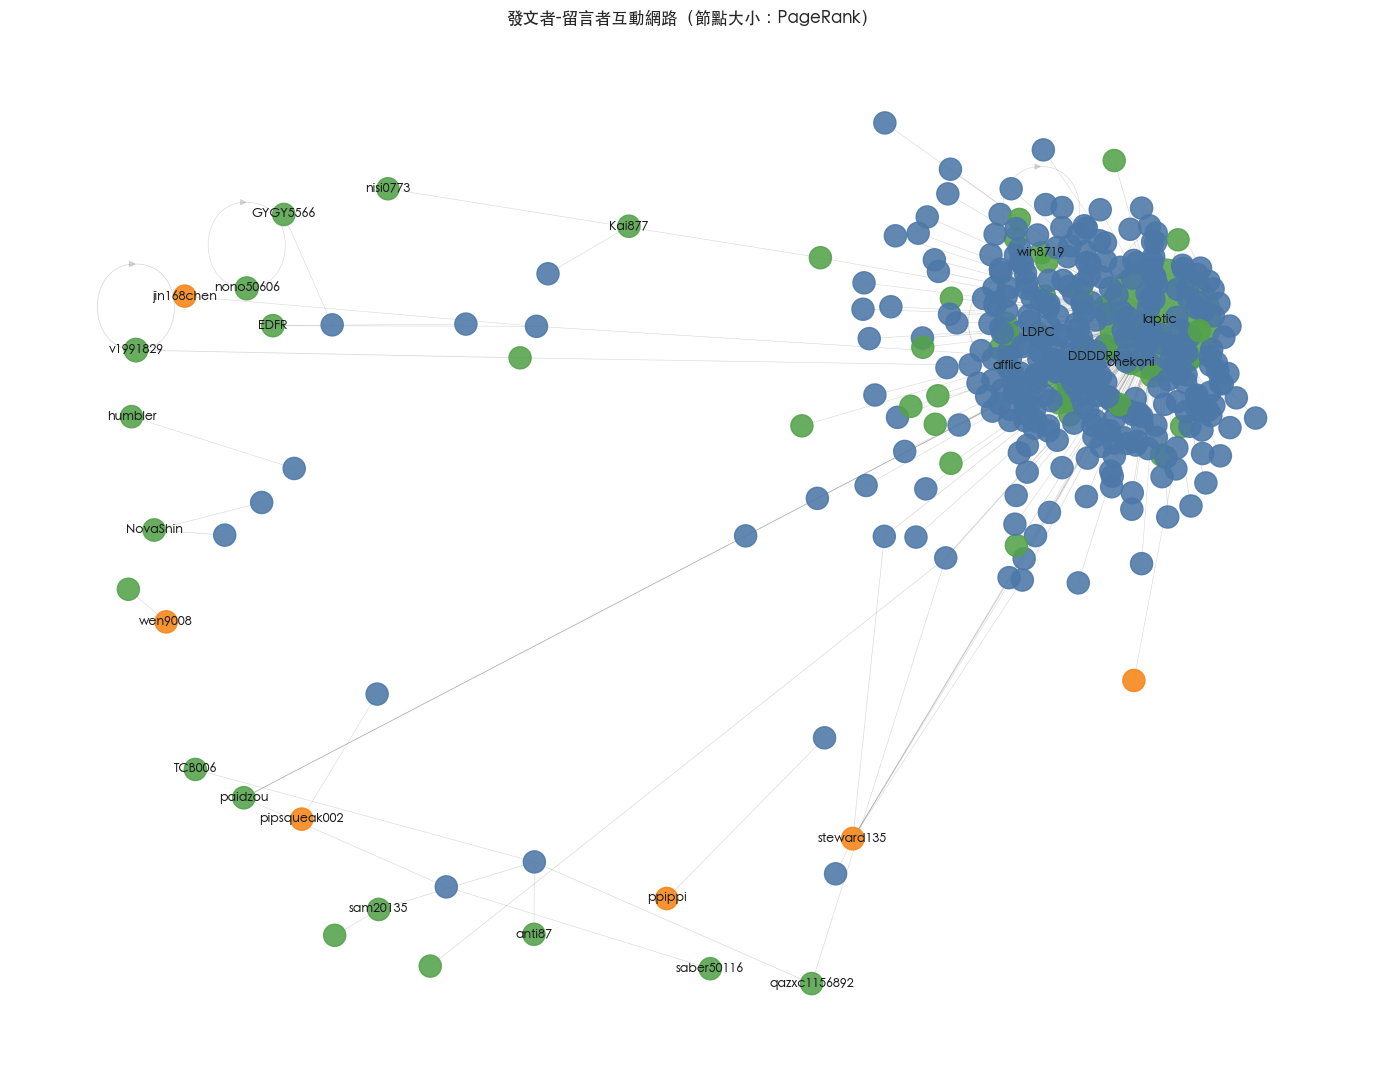

In [40]:
# 繪製靜態互動網路圖：節點大小使用 PageRank，顏色區分 commenter/poster/both。
# 這是網路視覺化的靜態版本；若有 pyvis 會輸出互動 HTML。
if interaction_G.number_of_nodes() > 0:
    role_color = {'commenter': '#4C78A8', 'poster': '#F58518', 'both': '#54A24B'}
    pagerank_map = social_centrality_df.set_index('user')['pagerank'].to_dict()
    node_sizes = [250 + 9000 * pagerank_map.get(n, 0) for n in interaction_G.nodes()]
    node_colors = [role_color.get(interaction_G.nodes[n].get('role', 'commenter'), '#999999') for n in interaction_G.nodes()]
    edge_weights = np.array([interaction_G[u][v].get('edge_count', 1) for u, v in interaction_G.edges()])
    edge_widths = 0.4 + 3.0 * (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(14, 11))
    pos = nx.spring_layout(interaction_G, seed=42, k=0.45)
    nx.draw_networkx_edges(interaction_G, pos, width=edge_widths, alpha=0.25, arrows=False, edge_color='#666666', ax=ax)
    nx.draw_networkx_nodes(interaction_G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.88, ax=ax)

    label_nodes = social_centrality_df.sort_values('pagerank', ascending=False).head(25)['user'].tolist()
    nx.draw_networkx_labels(interaction_G, pos, labels={n: n for n in label_nodes}, font_size=9, ax=ax)
    ax.set_title('發文者-留言者互動網路（節點大小：PageRank）')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'social_interaction_network_pagerank.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('沒有互動網路可繪製。')

In [41]:
# 如果環境有 pyvis，輸出 week14/week15 風格的互動式 HTML 網路圖；沒有 pyvis 則略過。
try:
    from pyvis.network import Network
    HAS_PYVIS = True
except Exception as exc:
    HAS_PYVIS = False
    print('未輸出 PyVis HTML；若要互動圖請安裝 pyvis。原因：', exc)

if HAS_PYVIS and interaction_G.number_of_nodes() > 0:
    net = Network(height='750px', width='100%', directed=True, notebook=True, cdn_resources='in_line')
    role_color = {'commenter': '#4C78A8', 'poster': '#F58518', 'both': '#54A24B'}
    centrality_map = social_centrality_df.set_index('user').to_dict('index')

    for node, attrs in interaction_G.nodes(data=True):
        metrics = centrality_map.get(node, {})
        role = attrs.get('role', 'commenter')
        title = (
            f"使用者: {node}<br>角色: {role}<br>"
            f"PageRank: {metrics.get('pagerank', 0):.5f}<br>"
            f"Authority: {metrics.get('authority_score', 0):.5f}<br>"
            f"Hub: {metrics.get('hub_score', 0):.5f}"
        )
        net.add_node(
            node,
            label=node,
            title=title,
            color=role_color.get(role, '#999999'),
            value=5 + 500 * metrics.get('pagerank', 0),
        )

    for u, v, attrs in interaction_G.edges(data=True):
        net.add_edge(
            u,
            v,
            value=attrs.get('edge_count', 1),
            title=f"互動次數: {attrs.get('edge_count', 0)}<br>淨分數: {attrs.get('net_score', 0):.2f}",
        )

    net.repulsion(node_distance=140, spring_length=180)
    html_path = FIGURE_DIR / 'social_interaction_network_pyvis.html'
    net.save_graph(str(html_path))
    print('已輸出 PyVis 互動圖：', html_path)

已輸出 PyVis 互動圖： /Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/output/figures/social_interaction_network_pyvis.html


## 16. Graph-level Measures 與最大連通子圖

除了節點中心性，我們也重視整張圖的結構指標。這一段將互動網路轉成無向圖，取最大連通子圖後計算 density、transitivity、average clustering、average shortest path length 與 diameter。

In [42]:
# 計算整體網路與最大連通子圖指標；最大連通子圖可避免斷裂網路造成距離指標無法計算。
def graph_level_measures(G):
    if G.number_of_nodes() == 0:
        return {}
    H = G.to_undirected()
    components = sorted(nx.connected_components(H), key=len, reverse=True)
    largest_nodes = components[0]
    H_largest = H.subgraph(largest_nodes).copy()

    measures = {
        'all_nodes': H.number_of_nodes(),
        'all_edges': H.number_of_edges(),
        'largest_component_nodes': H_largest.number_of_nodes(),
        'largest_component_edges': H_largest.number_of_edges(),
        'component_count': len(components),
        'density_largest': nx.density(H_largest),
        'transitivity_largest': nx.transitivity(H_largest),
        'average_clustering_largest': nx.average_clustering(H_largest, weight='weight'),
    }

    # 距離與直徑只在節點數大於 1 時有定義。
    if H_largest.number_of_nodes() > 1:
        unweighted = nx.Graph(H_largest)
        measures['average_shortest_path_largest'] = nx.average_shortest_path_length(unweighted)
        measures['diameter_largest'] = nx.diameter(unweighted)
    else:
        measures['average_shortest_path_largest'] = np.nan
        measures['diameter_largest'] = np.nan
    return measures, H_largest

if interaction_G.number_of_nodes() > 0:
    graph_measures, largest_interaction_G = graph_level_measures(interaction_G)
    graph_measures_df = pd.DataFrame([graph_measures])
else:
    largest_interaction_G = nx.Graph()
    graph_measures_df = pd.DataFrame()

display(graph_measures_df)
graph_measures_df.to_csv(TABLE_DIR / 'social_network_graph_measures.csv', index=False, encoding='utf-8-sig')

,all_nodes,all_edges,largest_component_nodes,largest_component_edges,component_count,density_largest,transitivity_largest,average_clustering_largest,average_shortest_path_largest,diameter_largest
0,396,400,380,391,9,0.00543,0.000047,0.000185,2.20743,9


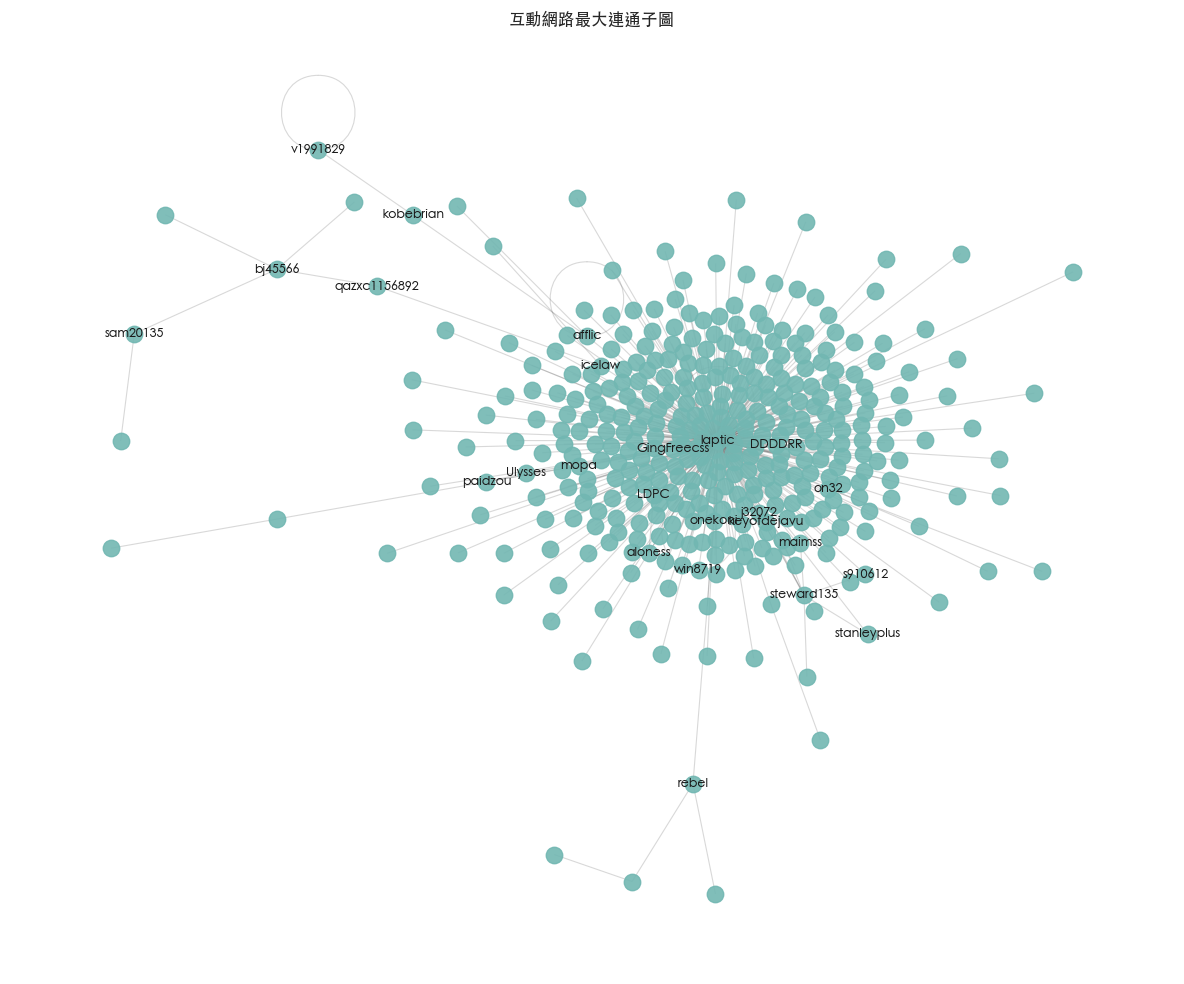

In [43]:
# 畫出最大連通子圖，對照 week15 的 max_sub 方法。
if largest_interaction_G.number_of_nodes() > 0:
    fig, ax = plt.subplots(figsize=(12, 10))
    pos = nx.spring_layout(largest_interaction_G, seed=42, k=0.5)
    nx.draw_networkx_edges(largest_interaction_G, pos, alpha=0.25, width=0.8, edge_color='#666666', ax=ax)
    nx.draw_networkx_nodes(largest_interaction_G, pos, node_size=140, node_color='#72B7B2', alpha=0.9, ax=ax)
    degree_map = dict(largest_interaction_G.degree())
    label_nodes = sorted(degree_map, key=degree_map.get, reverse=True)[:25]
    nx.draw_networkx_labels(largest_interaction_G, pos, labels={n: n for n in label_nodes}, font_size=9, ax=ax)
    ax.set_title('互動網路最大連通子圖')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'social_largest_component.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('沒有最大連通子圖可繪製。')

## 17. 關鍵詞共現矩陣與互動網路圖

week14 示範了矩陣轉網路圖與實體共現網路。這裡改用台積電資料中的重要詞彙：每篇文章內同時出現的關鍵詞形成一條共現邊，進一步計算 centrality 並輸出網路圖。

In [44]:
# 選取高頻且具有分析意義的關鍵詞，建立「文章內共現」矩陣。
# 每篇文章只計一次同一組詞的共現，避免長文章重複詞過度放大。
keyword_candidates = word_freq.head(120)['word'].astype(str).tolist()
keyword_candidates = [w for w in keyword_candidates if len(w) >= 2 and w not in stopwords]
keyword_candidates = keyword_candidates[:80]
keyword_set = set(keyword_candidates)

keyword_pair_counter = Counter()
keyword_doc_count = Counter()
for tokens in df['tokens']:
    present = sorted(set(tokens).intersection(keyword_set))
    keyword_doc_count.update(present)
    for i, w1 in enumerate(present):
        for w2 in present[i+1:]:
            keyword_pair_counter[(w1, w2)] += 1

keyword_edges = pd.DataFrame(
    [(a, b, c) for (a, b), c in keyword_pair_counter.items()],
    columns=['word1', 'word2', 'co_doc_count']
).sort_values('co_doc_count', ascending=False)

display(keyword_edges.head(30))
keyword_edges.to_csv(TABLE_DIR / 'keyword_cooccurrence_edges.csv', index=False, encoding='utf-8-sig')

,word1,word2,co_doc_count
808,Re,台積電,462
78,台積電,投資,410
63,台灣,台積電,366
176,台積電,標的,343
80,台積電,美國,318
81,台積電,股票,297
547,投信,排行,285
106,情報,排行,278
438,台積電,市場,278
98,外資,排行,276


In [45]:
# 建立關鍵詞共現網路，並計算 degree、weighted degree、eigenvector 與 betweenness。
keyword_G = nx.Graph()
for _, r in keyword_edges.head(180).iterrows():
    keyword_G.add_edge(r['word1'], r['word2'], weight=int(r['co_doc_count']))

if keyword_G.number_of_nodes() > 0:
    keyword_degree = dict(keyword_G.degree())
    keyword_weighted_degree = dict(keyword_G.degree(weight='weight'))
    try:
        keyword_eigen = nx.eigenvector_centrality(keyword_G, weight='weight', max_iter=1000)
    except Exception:
        keyword_eigen = nx.degree_centrality(keyword_G)
    keyword_bet = nx.betweenness_centrality(keyword_G, weight='weight')

    keyword_centrality_df = pd.DataFrame({
        'word': list(keyword_G.nodes()),
        'doc_count': [keyword_doc_count.get(w, 0) for w in keyword_G.nodes()],
        'degree': [keyword_degree.get(w, 0) for w in keyword_G.nodes()],
        'weighted_degree': [keyword_weighted_degree.get(w, 0) for w in keyword_G.nodes()],
        'eigenvector': [keyword_eigen.get(w, 0) for w in keyword_G.nodes()],
        'betweenness': [keyword_bet.get(w, 0) for w in keyword_G.nodes()],
    }).sort_values('weighted_degree', ascending=False)
else:
    keyword_centrality_df = pd.DataFrame()

display(keyword_centrality_df.head(25))
keyword_centrality_df.to_csv(TABLE_DIR / 'keyword_cooccurrence_centrality.csv', index=False, encoding='utf-8-sig')

,word,doc_count,degree,weighted_degree,eigenvector,betweenness
1,台積電,1441,58,11770,0.442209,0.853672
2,投資,443,18,3255,0.277669,0.051695
4,標的,360,14,2900,0.273312,0.002542
12,分析,278,13,2600,0.250385,0.000000
18,分類,239,13,2536,0.242044,0.000000
21,正文,227,13,2499,0.238428,0.000000
22,機制,227,13,2497,0.238515,0.000000
23,退場,223,13,2469,0.235776,0.000000
14,長期,269,13,2353,0.229602,0.000000
19,討論,238,13,2291,0.221657,0.000000


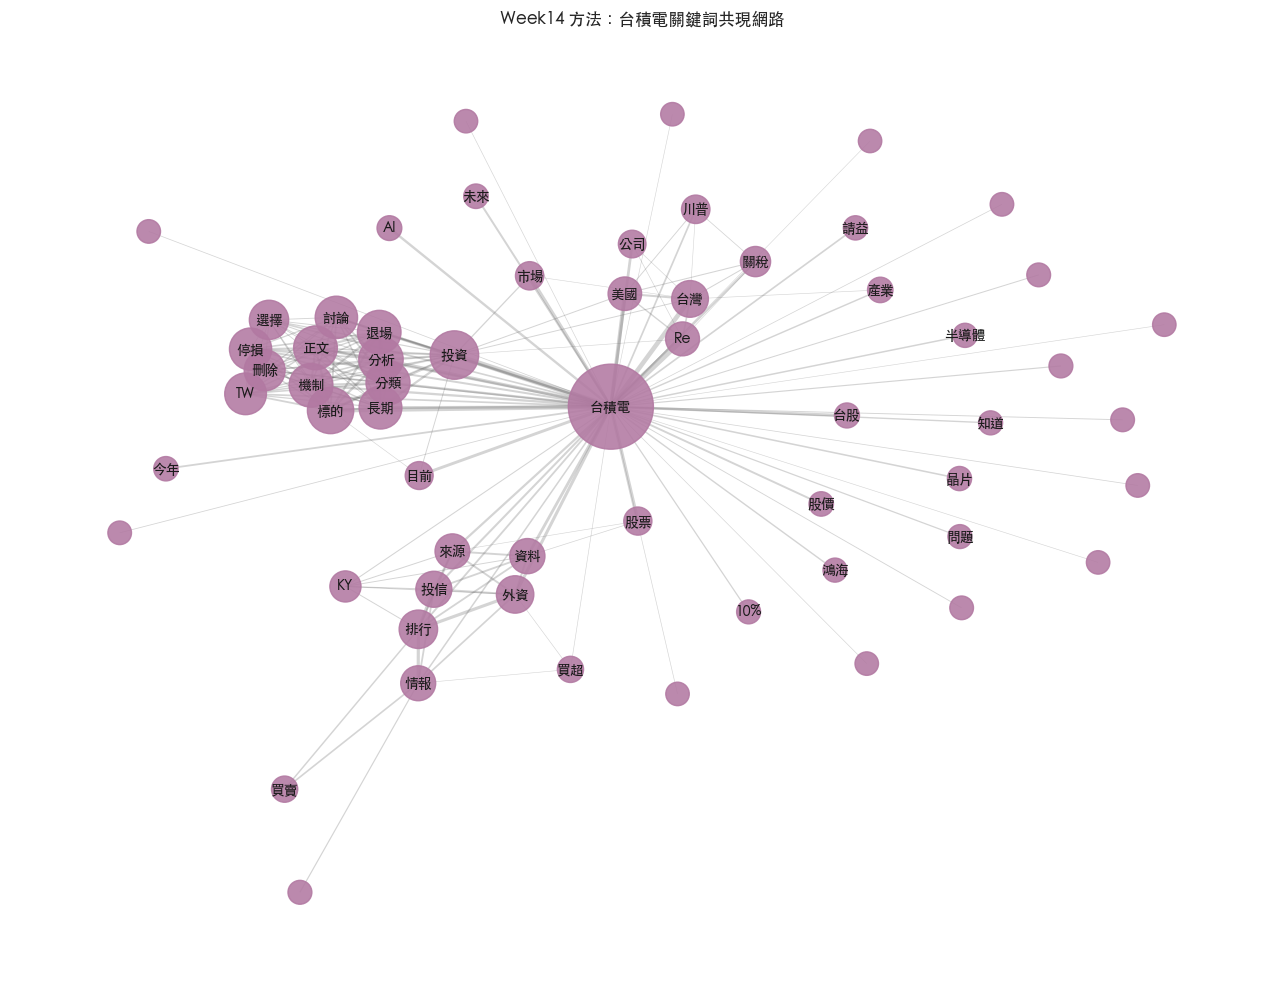

In [46]:
# 繪製關鍵詞共現網路；節點大小代表 weighted degree，邊寬代表共同出現於同一文章的次數。
if keyword_G.number_of_nodes() > 0:
    weighted_degree_map = keyword_centrality_df.set_index('word')['weighted_degree'].to_dict()
    max_wd = max(weighted_degree_map.values()) if weighted_degree_map else 1
    node_sizes = [250 + 3500 * weighted_degree_map.get(n, 0) / max_wd for n in keyword_G.nodes()]
    edge_weights = np.array([keyword_G[u][v]['weight'] for u, v in keyword_G.edges()])
    edge_widths = 0.4 + 4 * (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(13, 10))
    pos = nx.spring_layout(keyword_G, seed=42, k=0.58)
    nx.draw_networkx_edges(keyword_G, pos, width=edge_widths, alpha=0.28, edge_color='#666666', ax=ax)
    nx.draw_networkx_nodes(keyword_G, pos, node_size=node_sizes, node_color='#B279A2', alpha=0.88, ax=ax)
    label_nodes = keyword_centrality_df.head(45)['word'].tolist()
    nx.draw_networkx_labels(keyword_G, pos, labels={n: n for n in label_nodes}, font_size=10, ax=ax)
    ax.set_title('Week14 方法：台積電關鍵詞共現網路')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'keyword_cooccurrence_network.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('沒有關鍵詞共現網路可繪製。')

In [47]:
# 若有 pyvis，也輸出關鍵詞共現互動圖，方便在瀏覽器中拖曳查看群聚。
if 'HAS_PYVIS' in globals() and HAS_PYVIS and keyword_G.number_of_nodes() > 0:
    net = Network(height='750px', width='100%', directed=False, notebook=True, cdn_resources='in_line')
    metric_map = keyword_centrality_df.set_index('word').to_dict('index')
    for node in keyword_G.nodes():
        m = metric_map.get(node, {})
        net.add_node(
            node,
            label=node,
            value=5 + 0.03 * m.get('weighted_degree', 0),
            title=f"詞彙: {node}<br>文章數: {m.get('doc_count', 0)}<br>Weighted degree: {m.get('weighted_degree', 0):.0f}<br>Eigenvector: {m.get('eigenvector', 0):.5f}",
            color='#B279A2',
        )
    for u, v, attrs in keyword_G.edges(data=True):
        net.add_edge(u, v, value=attrs.get('weight', 1), title=f"共現文章數: {attrs.get('weight', 0)}")
    net.repulsion(node_distance=150, spring_length=180)
    html_path = FIGURE_DIR / 'keyword_cooccurrence_network_pyvis.html'
    net.save_graph(str(html_path))
    print('已輸出 PyVis 關鍵詞共現圖：', html_path)

已輸出 PyVis 關鍵詞共現圖： /Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/output/figures/keyword_cooccurrence_network_pyvis.html


## 18. 分析摘要與輸出


In [48]:
# 這裡的結論是根據目前資料與前面計算結果即時產生。
summary_rows = []
summary_rows.append(('資料期間', f"{df['artDate'].min()} 到 {df['artDate'].max()}"))
summary_rows.append(('文章數', f'{len(df):,}'))
summary_rows.append(('推文數', f'{len(comment_df):,}'))
summary_rows.append(('發文者數', f"{df['artPoster'].nunique():,}"))
summary_rows.append(('平均每篇推文數', f"{df['comment_count'].mean():.2f}"))
summary_rows.append(('推噓比', f"推 {df['push_count'].sum():,} / 噓 {df['boo_count'].sum():,} / 箭頭 {df['neutral_count'].sum():,}"))
if 'social_centrality_df' in globals() and len(social_centrality_df) > 0:
    summary_rows.append(('社群網路節點/邊', f"{interaction_G.number_of_nodes():,} 節點 / {interaction_G.number_of_edges():,} 邊"))
    summary_rows.append(('PageRank 最高使用者', social_centrality_df.sort_values('pagerank', ascending=False).iloc[0]['user']))
if 'graph_measures_df' in globals() and len(graph_measures_df) > 0:
    summary_rows.append(('最大連通子圖節點數', f"{int(graph_measures_df.iloc[0]['largest_component_nodes']):,}"))
if 'keyword_centrality_df' in globals() and len(keyword_centrality_df) > 0:
    summary_rows.append(('關鍵詞共現核心詞 Top 5', '、'.join(keyword_centrality_df.head(5)['word'].astype(str).tolist())))
summary_rows.append(('高頻詞 Top 10', '、'.join(word_freq.head(10)['word'].astype(str).tolist())))
summary_rows.append(('平均 TF-IDF Top 10', '、'.join(tfidf_rank.head(10)['word'].astype(str).tolist())))
summary_rows.append(('互動最高文章', df.sort_values('comment_count', ascending=False).iloc[0]['artTitle']))
summary_rows.append(('最正向文章', df.sort_values('lexicon_sentiment', ascending=False).iloc[0]['artTitle']))
summary_rows.append(('最負向文章', df.sort_values('lexicon_sentiment', ascending=True).iloc[0]['artTitle']))

summary_df = pd.DataFrame(summary_rows, columns=['項目', '結果'])
display(summary_df)
summary_df.to_csv(TABLE_DIR / 'analysis_summary.csv', index=False, encoding='utf-8-sig')

# 輸出文章層級分析表，包含互動、情緒、主題與關鍵欄位。
article_output = df[[
    'system_id', 'artDate', 'artPoster', 'artTitle', 'artUrl', 'comment_count',
    'push_count', 'boo_count', 'neutral_count', 'push_ratio', 'boo_ratio', 'net_push',
    'token_count', 'pos_word_count', 'neg_word_count', 'lexicon_sentiment', 'sentiment_label'
]].copy()
article_output = article_output.merge(doc_topic_df[['system_id', 'topic', 'topic_prob']], on='system_id', how='left')
article_output.to_csv(TABLE_DIR / 'article_level_analysis.csv', index=False, encoding='utf-8-sig')

print('已輸出表格至：', TABLE_DIR)
print('已輸出圖檔至：', FIGURE_DIR)

,項目,結果
0,資料期間,2025-06-01 01:18:14 到 2026-05-30 02:37:59
1,文章數,"2,279"
2,推文數,"316,501"
3,發文者數,724
4,平均每篇推文數,138.88
5,推噓比,"推 164,917 / 噓 27,934 / 箭頭 123,650"
6,社群網路節點/邊,396 節點 / 400 邊
7,PageRank 最高使用者,laptic
8,最大連通子圖節點數,380
9,關鍵詞共現核心詞 Top 5,台積電、投資、標的、分析、分類


已輸出表格至： /Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/output/tables
已輸出圖檔至： /Users/wuchunting/Downloads/SMA_2026S-main/SMA_FinalProject/output/figures
